# Paralelogramos e Casos Particulares

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (casos de congruência como ferramenta de demonstração), [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (ângulos alternos internos e colaterais internos entre paralelas), [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (ângulo reto e mediatriz) e [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) (definição de quadrilátero, o mapa dos quadriláteros notáveis e a convenção inclusiva, em que todo paralelogramo é um trapézio especial).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir paralelogramo e demonstrar suas propriedades (lados opostos congruentes, ângulos opostos congruentes, diagonais que se cortam ao meio) usando congruência de triângulos.
- Reconhecer as condições que garantem que um quadrilátero é paralelogramo (as recíprocas das propriedades).
- Definir e caracterizar retângulo, losango e quadrado, identificando as propriedades específicas de cada um (diagonais congruentes no retângulo; diagonais perpendiculares e bissetrizes no losango).
- Situar os três casos particulares na hierarquia dos quadriláteros e decidir se uma figura pertence a mais de uma categoria.

**Tempo estimado:** 70 a 85 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0409a_paralelogramos_e_casos_particulares.ipynb)

## O que muda e o que permanece quando o retângulo tomba?

Lembra das quatro varetas de [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb)? Duas de 4 dm, duas de 2,5 dm, presas pelas pontas com parafusos frouxos, formando um retângulo. Um empurrãozinho no canto de cima e o retângulo **tomba**, sem que nenhuma vareta mude de tamanho.

Lá, a pergunta foi "por que ele tomba?" (resposta: quatro lados não travam a forma). Agora a pergunta é outra, e ela vai organizar este notebook inteiro:

> **o que muda e o que permanece quando o retângulo tomba?**

Antes de olhar a resposta abaixo, pense um pouco: os lados opostos continuam paralelos? Continuam com o mesmo tamanho? E os ângulos? E as duas diagonais, que agora estão desenhadas em amarelo e lilás, e o ponto $M$ onde elas se cruzam?

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Circle, FancyBboxPatch, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas de desenho e de medida, as mesmas de 0408a_quadrilateros_definicao_elementos_e_trapezios
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=5)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Desenha o quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def orientacao(O, P, Q) -> float:
    """Multiplicação cruzada com sinal (0408a): zero se O, P e Q são colineares, positiva se o
    caminho O → P → Q vira para a esquerda e negativa se vira para a direita."""
    return (P[0] - O[0]) * (Q[1] - O[1]) - (P[1] - O[1]) * (Q[0] - O[0])


def area_com_sinal(vertices) -> float:
    """Área do polígono pela "fórmula do cadarço", com sinal (positiva no sentido anti-horário).
    Aqui só o SINAL nos interessa (as áreas ficam para o fim do módulo)."""
    n = len(vertices)
    return sum(orientacao((0, 0), vertices[k], vertices[(k + 1) % n]) for k in range(n)) / 2


def angulos_internos(vertices) -> list[float]:
    """Medidas (em graus) dos ângulos internos de um polígono simples, na ordem dos vértices."""
    n = len(vertices)
    sentido = 1 if area_com_sinal(vertices) > 0 else -1
    angulos = []
    for k in range(n):
        anterior, vertice, proximo = vertices[k - 1], vertices[k], vertices[(k + 1) % n]
        angulo = medir_angulo(vertice, anterior, proximo)
        if orientacao(anterior, vertice, proximo) * sentido < 0:  # virou "para o lado errado"
            angulo = 360 - angulo
        angulos.append(angulo)
    return angulos


def segmentos_se_cruzam(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 se cruzam formando um "X"."""
    return (orientacao(P1, P2, Q1) * orientacao(P1, P2, Q2) < 0
            and orientacao(Q1, Q2, P1) * orientacao(Q1, Q2, P2) < 0)


def tipo_de_quadrilatero(vertices) -> str:
    """'convexo', 'côncavo', 'cruzado' (dois lados se cruzam) ou 'degenerado' (três vértices
    consecutivos colineares)."""
    A, B, C, D = vertices
    giros = [orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % 4]) for k in range(4)]
    if any(math.isclose(g, 0, abs_tol=1e-9) for g in giros):
        return "degenerado"
    if segmentos_se_cruzam(A, B, C, D) or segmentos_se_cruzam(B, C, D, A):
        return "cruzado"
    if all(g > 0 for g in giros) or all(g < 0 for g in giros):
        return "convexo"
    return "côncavo"


def sao_paralelos(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 têm a mesma direção (inclinações iguais, a menos de 180°)."""
    diferenca = (direcao_de(P1, P2) - direcao_de(Q1, Q2)) % 180
    return math.isclose(diferenca, 0, abs_tol=1e-6) or math.isclose(diferenca, 180, abs_tol=1e-6)


def chapeu(letra: str) -> str:
    """Nome de ângulo com o chapéu (Â, B̂, ...), para títulos e rótulos dos gráficos."""
    return rf"$\hat{{{letra}}}$"


def desenhar_quadrilatero(ax, vertices, cor: str = COR_PONTO, largura: float = 2.5, estilo: str = "-",
                          preencher: bool = True) -> None:
    """Desenha os lados do polígono (na ordem dos vértices) e pinta levemente o interior."""
    if preencher:
        ax.add_patch(Polygon(vertices, closed=True, facecolor=cor, alpha=0.15, edgecolor="none"))
    n = len(vertices)
    for k in range(n):
        ax.plot(*zip(vertices[k], vertices[(k + 1) % n]), color=cor, lw=largura, linestyle=estilo)


def rotular_vertices(ax, vertices, nomes="ABCD", cor: str = COR_AVISO, distancia: float = 0.35,
                     tamanho: int = 13) -> None:
    """Marca os vértices e escreve os nomes do lado de fora da figura (afastando-se do centro dela)."""
    centro = np.mean(np.asarray(vertices, dtype=float), axis=0)
    for vertice, nome in zip(vertices, nomes):
        v = np.asarray(vertice, dtype=float)
        ax.plot(*v, "o", color=cor, markersize=7, zorder=5)
        afastar = v - centro
        afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
        ax.text(*(v + distancia * afastar), nome, color=NORD_TEXTO, fontsize=tamanho, fontweight="bold",
                ha="center", va="center")


def rotular_lado(ax, P, Q, texto: str, centro, cor: str = NORD_TEXTO_SEC, distancia: float = 0.3,
                 tamanho: int = 10) -> None:
    """Escreve `texto` junto ao meio do segmento PQ, do lado de fora da figura (longe de `centro`)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    meio = (P + Q) / 2
    normal = np.array([-(Q - P)[1], (Q - P)[0]]) / np.linalg.norm(Q - P)
    if np.dot(normal, meio - np.asarray(centro, dtype=float)) < 0:
        normal = -normal
    ax.text(*(meio + distancia * normal), texto, color=cor, fontsize=tamanho, ha="center", va="center",
            fontweight="bold")


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes (0402a)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2,
                zorder=6)


def desenhar_angulos_internos(ax, vertices, raio: float = 0.45, cores=None, raio_rotulo: float | None = None,
                              tamanho_fonte: int = 11) -> list[float]:
    """Pinta os ângulos internos do polígono com as medidas (o ângulo reto ganha o quadradinho)
    e devolve a lista das medidas."""
    angulos = angulos_internos(vertices)
    anti_horario = area_com_sinal(vertices) > 0
    n = len(vertices)
    cores = cores or [COR_DESTAQUE] * n
    for k, angulo in enumerate(angulos):
        vertice, anterior, proximo = vertices[k], vertices[k - 1], vertices[(k + 1) % n]
        inicio = direcao_de(vertice, proximo if anti_horario else anterior)
        desenhar_setor(ax, vertice, inicio, angulo, raio=raio, cor=cores[k], rotulo=f"{angulo:.0f}°",
                       raio_rotulo=1.9 * raio if raio_rotulo is None else raio_rotulo,
                       tamanho_fonte=tamanho_fonte)
    return angulos


# Ferramentas novas deste notebook
def paralelogramo_por_lados(lado_AB: float, lado_AD: float, angulo_A: float, inclinacao: float = 0.0,
                            origem=(0.0, 0.0)) -> list[np.ndarray]:
    """Vértices A, B, C, D do paralelogramo com lados AB e AD e ângulo Â dados (em graus).
    `inclinacao` é a direção do lado AB. O vértice C é o "quarto canto": C = B + D − A."""
    A = np.array(origem, dtype=float)
    B = A + lado_AB * direcao(inclinacao)
    D = A + lado_AD * direcao(inclinacao + angulo_A)
    return [A, B, B + D - A, D]


def losango_por_diagonais(d1: float, d2: float, giro: float = 0.0, centro=(0.0, 0.0)) -> list[np.ndarray]:
    """Vértices A, B, C, D do losango cujas diagonais AC (medida d1) e BD (medida d2) se cruzam ao
    meio, em ângulo reto, no `centro`. `giro` é a direção da diagonal AC, em graus."""
    M = np.array(centro, dtype=float)
    A, C = M - d1 / 2 * direcao(giro), M + d1 / 2 * direcao(giro)
    B, D = M - d2 / 2 * direcao(giro + 90), M + d2 / 2 * direcao(giro + 90)
    return [A, B, C, D]


def desenhar_diagonais(ax, vertices, cores=(COR_AVISO, COR_EXTRA), largura: float = 2.2,
                       nome_meio: str = "M") -> np.ndarray | None:
    """Desenha as diagonais AC e BD (tracejadas, cada uma com uma cor), marca o ponto em que elas se
    cruzam e devolve esse ponto (None se elas forem paralelas)."""
    A, B, C, D = vertices
    ax.plot(*zip(A, C), color=cores[0], lw=largura, linestyle="--")
    ax.plot(*zip(B, D), color=cores[1], lw=largura, linestyle="--")
    M = cruzamento(A, direcao_de(A, C), B, direcao_de(B, D))
    if M is not None and nome_meio:
        desenhar_ponto(ax, M, nome_meio, cor=NORD_TEXTO, deslocamento=(0.12, -0.42))
    return M


def escrever_checklist(ax, itens, titulo: str = "") -> None:
    """Painel de texto com uma linha por item (texto, ok): ✓ verde quando vale, ✗ vermelho quando não."""
    ax.set_facecolor(NORD_FUNDO)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    if titulo:
        ax.text(0.0, 0.97, titulo, color=NORD_TEXTO, fontsize=12, fontweight="bold", va="top")
    passo = min(0.13, 0.85 / max(len(itens), 1))
    for k, (texto, ok) in enumerate(itens):
        ax.text(0.0, 0.84 - k * passo, f"{'✓' if ok else '✗'}  {texto}", color=COR_DESTAQUE if ok else COR_ALERTA,
                fontsize=11, va="top")

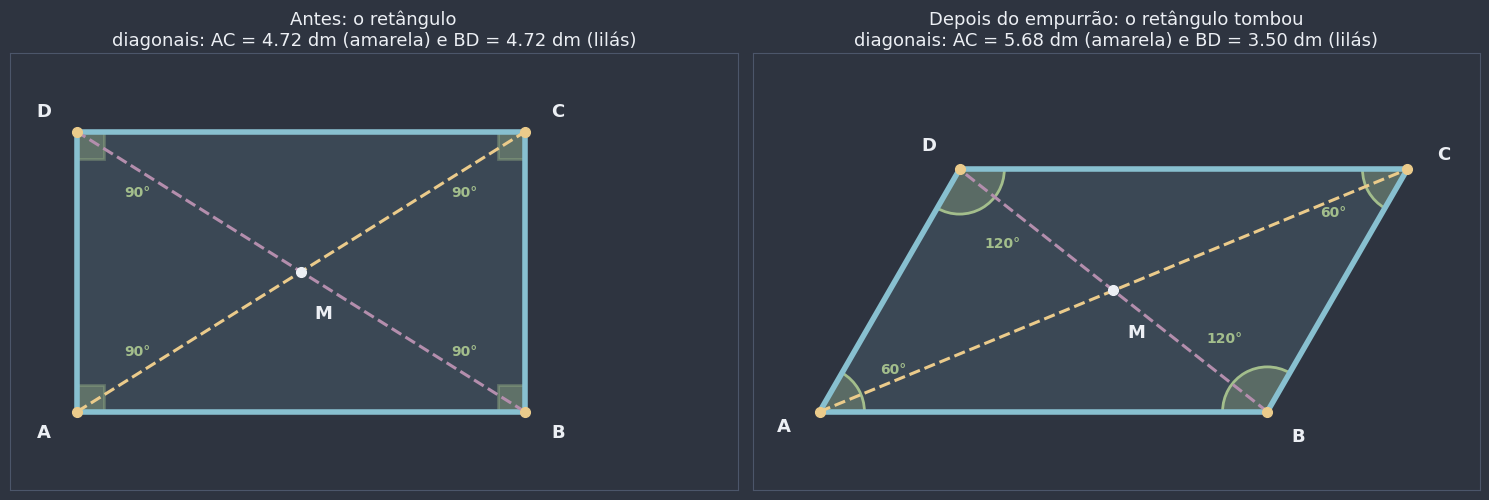

medida,retângulo,depois do tombo,o que aconteceu
lados AB e CD (dm),4.00 e 4.00,4.00 e 4.00,permanece ✅
lados BC e DA (dm),2.50 e 2.50,2.50 e 2.50,permanece ✅
AB ∥ DC e BC ∥ AD?,sim,sim,permanece ✅
"ângulos Â, B̂, Ĉ, D̂","90°, 90°, 90°, 90°","60°, 120°, 60°, 120°",mudou 🔄
diagonais AC e BD (dm),4.72 e 4.72,5.68 e 3.50,mudou 🔄
M é o ponto médio de AC e de BD?,sim,sim,permanece ✅


In [2]:
def resumo_das_medidas(vertices) -> dict[str, str]:
    """As medidas que vamos comparar antes e depois do tombo, já formatadas como texto."""
    A, B, C, D = vertices
    M = cruzamento(A, direcao_de(A, C), B, direcao_de(B, D))
    paralelos = sao_paralelos(A, B, D, C) and sao_paralelos(B, C, A, D)
    meio = np.allclose(M, ponto_medio(A, C)) and np.allclose(M, ponto_medio(B, D))
    return {
        "lados AB e CD (dm)": f"{math.dist(A, B):.2f} e {math.dist(C, D):.2f}",
        "lados BC e DA (dm)": f"{math.dist(B, C):.2f} e {math.dist(D, A):.2f}",
        "AB ∥ DC e BC ∥ AD?": "sim" if paralelos else "não",
        "ângulos Â, B̂, Ĉ, D̂": ", ".join(f"{a:.0f}°" for a in angulos_internos(vertices)),
        "diagonais AC e BD (dm)": f"{math.dist(A, C):.2f} e {math.dist(B, D):.2f}",
        "M é o ponto médio de AC e de BD?": "sim" if meio else "não",
    }


retangulo = paralelogramo_por_lados(4, 2.5, 90)
tombado = paralelogramo_por_lados(4, 2.5, 60)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5.4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, vertices, titulo in [(eixos[0], retangulo, "Antes: o retângulo"),
                             (eixos[1], tombado, "Depois do empurrão: o retângulo tombou")]:
    A, B, C, D = vertices
    preparar_eixo(ax, [(-0.6, -0.7), (5.9, 3.2)], margem=0)
    desenhar_quadrilatero(ax, vertices, cor=COR_PONTO, largura=4)
    desenhar_angulos_internos(ax, vertices, raio=0.4, tamanho_fonte=10)
    desenhar_diagonais(ax, vertices)
    rotular_vertices(ax, vertices)
    ax.set_title(f"{titulo}\ndiagonais: AC = {math.dist(A, C):.2f} dm (amarela) e BD = {math.dist(B, D):.2f} dm (lilás)",
                 color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

antes, depois = resumo_das_medidas(retangulo), resumo_das_medidas(tombado)
display(pd.DataFrame({
    "medida": list(antes),
    "retângulo": list(antes.values()),
    "depois do tombo": list(depois.values()),
    "o que aconteceu": ["permanece ✅" if antes[chave] == depois[chave] else "mudou 🔄" for chave in antes],
}).style.hide(axis="index"))

🕹️ **Widget interativo:** o slider `ângulo em A` tomba o quadrilátero de varetas para um lado ou para o outro (90° é o retângulo de pé). O painel da direita confere, a cada posição, cinco propriedades. Tente descobrir: quais itens ficam **sempre** com ✓, e quais só ganham ✓ quando o ângulo volta a 90°?

In [3]:
def explorar_tombo(angulo_A: int) -> None:
    vertices = paralelogramo_por_lados(4, 2.5, angulo_A)
    A, B, C, D = vertices
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.7, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-2.8, -0.7), (6.8, 3.2)], margem=0)
    desenhar_quadrilatero(ax, vertices, cor=COR_PONTO, largura=4)
    desenhar_angulos_internos(ax, vertices, raio=0.4, tamanho_fonte=10)
    M = desenhar_diagonais(ax, vertices)
    rotular_vertices(ax, vertices)
    itens = [
        ("lados opostos congruentes (4 e 2,5)",
         math.isclose(math.dist(A, B), math.dist(C, D)) and math.isclose(math.dist(B, C), math.dist(D, A))),
        ("lados opostos paralelos", sao_paralelos(A, B, D, C) and sao_paralelos(B, C, A, D)),
        ("diagonais se cortam ao meio", np.allclose(M, ponto_medio(A, C)) and np.allclose(M, ponto_medio(B, D))),
        ("quatro ângulos retos", all(math.isclose(a, 90, abs_tol=1e-6) for a in angulos_internos(vertices))),
        (f"diagonais congruentes (AC = {math.dist(A, C):.2f}, BD = {math.dist(B, D):.2f})",
         math.isclose(math.dist(A, C), math.dist(B, D))),
    ]
    escrever_checklist(ax_lista, itens, "O que vale nesta posição?")
    situacao = "de pé: é um RETÂNGULO" if angulo_A == 90 else "tombado: um paralelogramo que não é retângulo"
    ax.set_title(f"Ângulo em A = {angulo_A}° ({situacao})", color=COR_DESTAQUE if angulo_A == 90 else COR_PONTO,
                 fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_tombo,
    angulo_A=widgets.IntSlider(value=60, min=30, max=150, step=5, description="ângulo em A (°):",
                               style={"description_width": "initial"}),
);

interactive(children=(IntSlider(value=60, description='ângulo em A (°):', max=150, min=30, step=5, style=Slide…

A tabela e o widget respondem à pergunta do gancho:

- **Permanece:** os lados opostos continuam **paralelos** e **congruentes** (são as mesmas varetas), e o ponto $M$ em que as diagonais se cruzam continua sendo **o meio de cada uma delas**.
- **Muda:** os ângulos deixam de ser retos, e as duas diagonais deixam de ter o mesmo comprimento (uma "estica" e a outra "encolhe").

E é isso que organiza o notebook: o que **permanece** é propriedade de **todo paralelogramo** (seções 1 e 2); o que **se perde** no tombo era exclusivo do **retângulo** (seção 3). Depois vêm o **losango** (seção 4), o **quadrado** e o mapa completo (seção 5).

🎯 **Aplicação prática — mecanismos articulados:** essa "deformação que preserva o paralelismo" é usada de propósito em vários objetos. O **pantógrafo** (o braço articulado que copia desenhos ampliados, e também a haste que leva energia da rede elétrica para trens e bondes), o **braço de um abajur articulado**, os **suportes de TV** que se afastam da parede e certas **pontes levadiças** são feitos de paralelogramos articulados: os braços giram, mas a peça da ponta continua sempre paralela à peça presa na base. Na seção 1 você vai ver o porquê.

## 1. Paralelogramo: definição e propriedades

📌 **Definição formal (paralelogramo):** **paralelogramo** é o quadrilátero que tem os **dois pares de lados opostos paralelos**. Ou seja, $ABCD$ é paralelogramo quando

$$\overline{AB} \parallel \overline{DC} \qquad \text{e} \qquad \overline{AD} \parallel \overline{BC}.$$

Pelo mapa de [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) (convenção inclusiva), todo paralelogramo é um **trapézio** especial, com dois pares de bases. Então tudo o que vale para trapézios vale aqui, só que duas vezes.

📌 **Teorema (propriedades do paralelogramo):** em todo paralelogramo $ABCD$:
1. os **lados opostos são congruentes**: $AB = CD$ e $AD = BC$;
2. os **ângulos opostos são congruentes**: $\hat{A} = \hat{C}$ e $\hat{B} = \hat{D}$;
3. os **ângulos consecutivos são suplementares**: $\hat{A} + \hat{B} = \hat{B} + \hat{C} = \hat{C} + \hat{D} = \hat{D} + \hat{A} = 180^\circ$;
4. as **diagonais se cortam ao meio**: se $M$ é o ponto em que $\overline{AC}$ e $\overline{BD}$ se cruzam, então $AM = MC$ e $BM = MD$.

**A propriedade 3** é a mais rápida: cada lado do paralelogramo é uma **transversal** cortando o outro par de lados paralelos, e os **colaterais internos** entre paralelas são suplementares ([`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb)). Por exemplo, $\overline{AB}$ corta as paralelas $\overleftrightarrow{AD}$ e $\overleftrightarrow{BC}$, e $\hat{A}$ e $\hat{B}$ são colaterais internos.

**As propriedades 1 e 2** são o fio que ficou solto no Desafio 5 de [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb). Lá, você mediu os ângulos; agora, com os alternos internos de [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb), dá para justificar cada passo. A ideia de sempre: traçar a diagonal $\overline{AC}$ e encontrar dois triângulos congruentes.

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $B\hat{A}C \equiv D\hat{C}A$ | alternos internos: $\overleftrightarrow{AB} \parallel \overleftrightarrow{DC}$ cortadas pela transversal $\overleftrightarrow{AC}$ (0406a) |
| 2 | $B\hat{C}A \equiv D\hat{A}C$ | alternos internos: $\overleftrightarrow{AD} \parallel \overleftrightarrow{BC}$ cortadas pela transversal $\overleftrightarrow{AC}$ (0406a) |
| 3 | $\overline{AC} \equiv \overline{CA}$ | lado comum aos dois triângulos |
| 4 | $\triangle ABC \equiv \triangle CDA$ | caso ALA: passos 1, 3 e 2 (0405a) |
| 5 | $AB = CD$ e $BC = DA$ | lados correspondentes de triângulos congruentes (**propriedade 1**) |
| 6 | $\hat{B} \equiv \hat{D}$ | ângulos correspondentes de triângulos congruentes |
| 7 | $\hat{A} = B\hat{A}C + C\hat{A}D = D\hat{C}A + B\hat{C}A = \hat{C}$ | a diagonal divide $\hat{A}$ e $\hat{C}$ em duas partes; passos 1 e 2 (**propriedade 2**) ∎ |

**A propriedade 4** usa a mesma estratégia, agora com as **duas** diagonais. Seja $M$ o ponto em que elas se cruzam:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $M\hat{A}B \equiv M\hat{C}D$ | alternos internos: $\overleftrightarrow{AB} \parallel \overleftrightarrow{DC}$, transversal $\overleftrightarrow{AC}$ |
| 2 | $AB = CD$ | propriedade 1 |
| 3 | $A\hat{B}M \equiv C\hat{D}M$ | alternos internos: $\overleftrightarrow{AB} \parallel \overleftrightarrow{DC}$, transversal $\overleftrightarrow{BD}$ |
| 4 | $\triangle ABM \equiv \triangle CDM$ | caso ALA: passos 1, 2 e 3 |
| 5 | $AM = CM$ e $BM = DM$ | lados correspondentes: $M$ é o ponto médio das duas diagonais ∎ |

**A representação numérica.** Vamos conferir as quatro propriedades num paralelogramo dado por coordenadas. Para achar o ponto $M$ em que as diagonais se cruzam, usamos a função `cruzamento` (o sistema linear 2×2 de [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb)), e depois comparamos $M$ com os pontos médios de $\overline{AC}$ e de $\overline{BD}$.

In [4]:
A, B, D = np.array([0.0, 0.0]), np.array([5.0, 1.0]), np.array([1.5, 3.0])
C = B + D - A  # o "quarto canto" de um paralelogramo
paralelogramo = [A, B, C, D]
print(f"A = {A},  B = {B},  C = {C},  D = {D}")
print(f"AB ∥ DC? {sao_paralelos(A, B, D, C)}    AD ∥ BC? {sao_paralelos(A, D, B, C)}\n")

# Propriedade 1: lados opostos
display(pd.DataFrame([
    {"par de lados opostos": "AB e CD", "medidas": f"{math.dist(A, B):.3f} e {math.dist(C, D):.3f}",
     "congruentes?": "✅" if math.isclose(math.dist(A, B), math.dist(C, D)) else "❌"},
    {"par de lados opostos": "BC e DA", "medidas": f"{math.dist(B, C):.3f} e {math.dist(D, A):.3f}",
     "congruentes?": "✅" if math.isclose(math.dist(B, C), math.dist(D, A)) else "❌"},
]).style.hide(axis="index"))

# Propriedades 2 e 3: ângulos opostos e consecutivos
a_A, a_B, a_C, a_D = angulos_internos(paralelogramo)
display(pd.DataFrame([
    {"Â": f"{a_A:.2f}°", "B̂": f"{a_B:.2f}°", "Ĉ": f"{a_C:.2f}°", "D̂": f"{a_D:.2f}°",
     "Â = Ĉ?": "✅" if math.isclose(a_A, a_C) else "❌", "B̂ = D̂?": "✅" if math.isclose(a_B, a_D) else "❌",
     "Â + B̂": f"{a_A + a_B:.2f}°", "B̂ + Ĉ": f"{a_B + a_C:.2f}°", "Ĉ + D̂": f"{a_C + a_D:.2f}°",
     "D̂ + Â": f"{a_D + a_A:.2f}°"},
]).style.hide(axis="index"))

# Propriedade 4: as diagonais se cortam ao meio
M = cruzamento(A, direcao_de(A, C), B, direcao_de(B, D))
display(pd.DataFrame([
    {"ponto": "M (cruzamento das diagonais)", "coordenadas": f"({M[0]:.3f}, {M[1]:.3f})"},
    {"ponto": "ponto médio de AC", "coordenadas": "({:.3f}, {:.3f})".format(*ponto_medio(A, C))},
    {"ponto": "ponto médio de BD", "coordenadas": "({:.3f}, {:.3f})".format(*ponto_medio(B, D))},
]).style.hide(axis="index"))
print(f"AM = {math.dist(A, M):.3f},  MC = {math.dist(M, C):.3f}   |   BM = {math.dist(B, M):.3f},  MD = {math.dist(M, D):.3f}")
print(f"mas AC = {math.dist(A, C):.3f} e BD = {math.dist(B, D):.3f}: as diagonais NÃO são congruentes")

A = [0. 0.],  B = [5. 1.],  C = [6.5 4. ],  D = [1.5 3. ]
AB ∥ DC? True    AD ∥ BC? True



par de lados opostos,medidas,congruentes?
AB e CD,5.099 e 5.099,✅
BC e DA,3.354 e 3.354,✅


Â,B̂,Ĉ,D̂,Â = Ĉ?,B̂ = D̂?,Â + B̂,B̂ + Ĉ,Ĉ + D̂,D̂ + Â
52.13°,127.87°,52.13°,127.87°,✅,✅,180.00°,180.00°,180.00°,180.00°


ponto,coordenadas
M (cruzamento das diagonais),"(3.250, 2.000)"
ponto médio de AC,"(3.250, 2.000)"
ponto médio de BD,"(3.250, 2.000)"


AM = 3.816,  MC = 3.816   |   BM = 2.016,  MD = 2.016
mas AC = 7.632 e BD = 4.031: as diagonais NÃO são congruentes


E a representação gráfica das duas demonstrações. À esquerda, a diagonal $\overline{AC}$ e os triângulos congruentes $\triangle ABC$ e $\triangle CDA$: os ângulos marcados com a mesma cor são os alternos internos congruentes, e os tracinhos marcam os lados opostos congruentes. À direita, as duas diagonais e os triângulos $\triangle ABM$ e $\triangle CDM$: cada diagonal fica dividida em duas metades iguais.

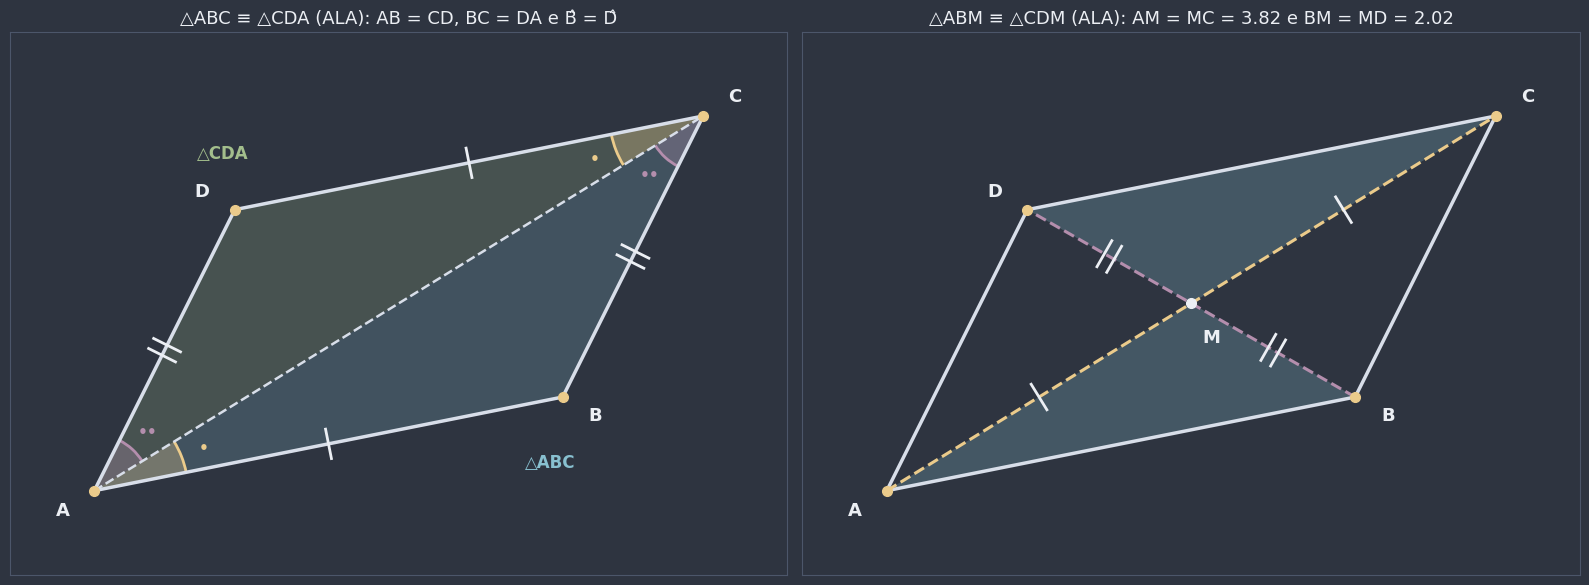

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.8))
fig.patch.set_facecolor(NORD_FUNDO)

# Esquerda: propriedades 1 e 2, pela diagonal AC
preparar_eixo(ax1, paralelogramo, margem=0.9)
ax1.add_patch(Polygon([A, B, C], closed=True, facecolor=COR_PONTO, alpha=0.22, edgecolor="none"))
ax1.add_patch(Polygon([C, D, A], closed=True, facecolor=COR_DESTAQUE, alpha=0.22, edgecolor="none"))
desenhar_quadrilatero(ax1, paralelogramo, cor=NORD_TEXTO_SEC, largura=2.5, preencher=False)
ax1.plot(*zip(A, C), color=NORD_TEXTO_SEC, lw=1.8, linestyle="--")
desenhar_arco(ax1, A, B, C, raio=1.0, cor=COR_AVISO, rotulo="•", raio_rotulo=1.25)
desenhar_arco(ax1, C, D, A, raio=1.0, cor=COR_AVISO, rotulo="•", raio_rotulo=1.25)
desenhar_arco(ax1, C, A, B, raio=0.6, cor=COR_EXTRA, rotulo="••", raio_rotulo=0.85)
desenhar_arco(ax1, A, C, D, raio=0.6, cor=COR_EXTRA, rotulo="••", raio_rotulo=0.85)
for P, Q, tracos in ((A, B, 1), (C, D, 1), (B, C, 2), (D, A, 2)):
    marcar_congruentes(ax1, P, Q, tracos)
rotular_vertices(ax1, paralelogramo, distancia=0.4)
ax1.text(4.6, 0.25, "△ABC", color=COR_PONTO, fontsize=12, fontweight="bold")
ax1.text(1.1, 3.55, "△CDA", color=COR_DESTAQUE, fontsize=12, fontweight="bold")
ax1.set_title("△ABC ≡ △CDA (ALA): AB = CD, BC = DA e B̂ = D̂", color=NORD_TEXTO, fontsize=13)

# Direita: propriedade 4, pelas duas diagonais
preparar_eixo(ax2, paralelogramo, margem=0.9)
ax2.add_patch(Polygon([A, B, M], closed=True, facecolor=COR_PONTO, alpha=0.25, edgecolor="none"))
ax2.add_patch(Polygon([C, D, M], closed=True, facecolor=COR_PONTO, alpha=0.25, edgecolor="none"))
desenhar_quadrilatero(ax2, paralelogramo, cor=NORD_TEXTO_SEC, largura=2.5, preencher=False)
desenhar_diagonais(ax2, paralelogramo)
for P, Q, tracos in ((A, M, 1), (M, C, 1), (B, M, 2), (M, D, 2)):
    marcar_congruentes(ax2, P, Q, tracos)
rotular_vertices(ax2, paralelogramo, distancia=0.4)
ax2.set_title(f"△ABM ≡ △CDM (ALA): AM = MC = {math.dist(A, M):.2f} e BM = MD = {math.dist(B, M):.2f}",
              color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕵️ **Curiosidade histórica:** essas propriedades estão nos *Elementos* de Euclides (c. 300 a.C.). A **Proposição 34 do Livro I** diz que, num paralelogramo, "os lados e os ângulos opostos são iguais, e a diagonal o divide em duas partes iguais", e a prova é a mesma da nossa tabela: a diagonal e os alternos internos. É também nessa proposição que a palavra *parallelogrammon* ("limitado por linhas paralelas", em grego) aparece pela primeira vez nos *Elementos*.

🕹️ **Widget interativo:** monte o seu próprio paralelogramo. Os sliders controlam os dois lados que saem de $A$: o `lado AB` e a `inclinação de AB`, e o `lado AD` e a `inclinação de AD` (as inclinações em graus, a partir da horizontal). O vértice $C$ é calculado sozinho como o "quarto canto" ($C = B + D - A$). O painel da direita confere as quatro propriedades, com as medidas. Tente deixar as duas inclinações iguais (ou diferindo de 180°): o que acontece com a figura?

In [ ]:
def explorar_paralelogramo(lado_AB: float, inclinacao_AB: int, lado_AD: float, inclinacao_AD: int) -> None:
    A = np.array([0.0, 0.0])
    B = lado_AB * direcao(inclinacao_AB)
    D = lado_AD * direcao(inclinacao_AD)
    vertices = [A, B, B + D, D]
    A, B, C, D = vertices
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14.5, 5.6), gridspec_kw={"width_ratios": [1.45, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, vertices, margem=1.0)
    if (inclinacao_AD - inclinacao_AB) % 180 == 0:
        ax.plot(*zip(*vertices), color=COR_ALERTA, lw=3)
        rotular_vertices(ax, vertices)
        ax.set_title("Inclinações iguais (a menos de 180°): AB e AD ficam na mesma reta\n"
                     "e a figura achata num segmento. Não é um quadrilátero!", color=COR_ALERTA, fontsize=13)
        escrever_checklist(ax_lista, [])
    else:
        desenhar_quadrilatero(ax, vertices, cor=COR_PONTO, largura=3)
        a_A, a_B, a_C, a_D = desenhar_angulos_internos(ax, vertices, raio=0.45, tamanho_fonte=10)
        M = desenhar_diagonais(ax, vertices)
        rotular_vertices(ax, vertices, distancia=0.4)
        itens = [
            (f"1. lados opostos ≡:  AB = CD = {math.dist(A, B):.2f},  BC = DA = {math.dist(B, C):.2f}",
             math.isclose(math.dist(A, B), math.dist(C, D)) and math.isclose(math.dist(B, C), math.dist(D, A))),
            (f"2. ângulos opostos ≡:  Â = Ĉ = {a_A:.0f}°,  B̂ = D̂ = {a_B:.0f}°",
             math.isclose(a_A, a_C) and math.isclose(a_B, a_D)),
            (f"3. consecutivos suplementares:  Â + B̂ = {a_A + a_B:.0f}°",
             all(math.isclose(s, 180) for s in (a_A + a_B, a_B + a_C, a_C + a_D, a_D + a_A))),
            (f"4. diagonais se cortam ao meio:  AM = MC = {math.dist(A, M):.2f}",
             np.allclose(M, ponto_medio(A, C)) and np.allclose(M, ponto_medio(B, D))),
            (f"   (e BM = MD = {math.dist(B, M):.2f})", np.allclose(M, ponto_medio(B, D))),
        ]
        escrever_checklist(ax_lista, itens, "As propriedades do paralelogramo")
        ax.set_title(f"Paralelogramo ABCD: Â = {a_A:.0f}°, diagonais AC = {math.dist(A, C):.2f} e "
                     f"BD = {math.dist(B, D):.2f}", color=COR_DESTAQUE, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_paralelogramo,
    lado_AB=widgets.FloatSlider(value=4, min=1, max=6, step=0.5, description="lado AB:"),
    inclinacao_AB=widgets.IntSlider(value=10, min=0, max=90, step=5, description="inclinação de AB (°):",
                                    style={"description_width": "initial"}),
    lado_AD=widgets.FloatSlider(value=2.5, min=1, max=5, step=0.5, description="lado AD:"),
    inclinacao_AD=widgets.IntSlider(value=70, min=0, max=180, step=5, description="inclinação de AD (°):",
                                    style={"description_width": "initial"}),
);

interactive(children=(FloatSlider(value=4.0, description='lado AB:', max=6.0, min=1.0, step=0.5), IntSlider(va…

Por mais torto que você deixe o paralelogramo, as quatro propriedades continuam com ✓. Elas não dependem de medidas especiais: dependem **só** do paralelismo.

🎯 **Aplicação prática — o suporte articulado:** é por isso que os mecanismos do gancho funcionam. Num suporte de TV articulado, a peça presa na parede ($\overline{AD}$) e a peça que segura a tela ($\overline{BC}$) são ligadas por **dois braços de mesmo comprimento** ($\overline{AB}$ e $\overline{DC}$). Com $AB = DC$ e $AD = BC$, a figura é sempre um paralelogramo (você vai ver o porquê na seção 2), então $\overline{BC}$ fica **sempre paralela** a $\overline{AD}$: os braços sobem e descem, mas a tela continua na vertical, sem precisar de nenhum motor para "endireitá-la".

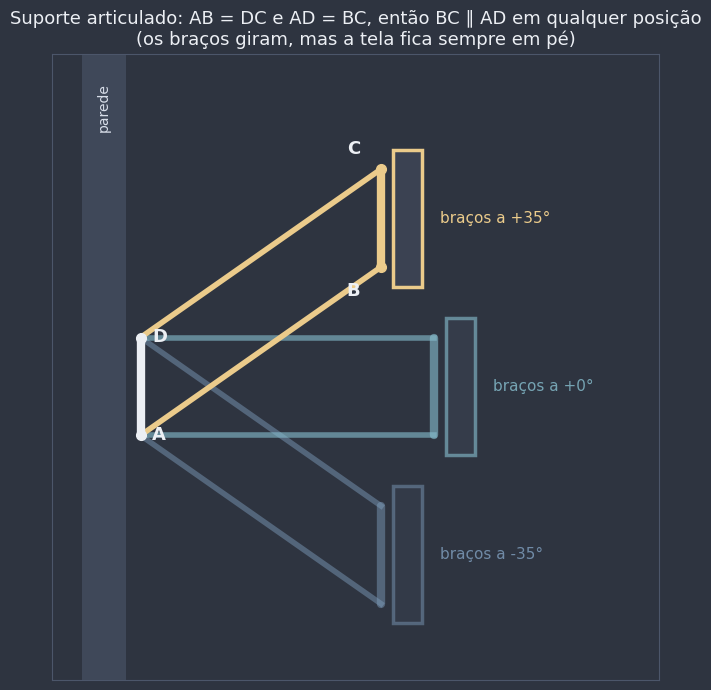

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-0.8, -2.4), (5.2, 3.8)], margem=0.1)
ax.add_patch(Polygon([(-0.6, -2.5), (-0.15, -2.5), (-0.15, 3.9), (-0.6, 3.9)], closed=True, facecolor=NORD_LINHA,
                     alpha=0.6, edgecolor="none"))  # a parede
ax.text(-0.38, 3.6, "parede", color=NORD_TEXTO_SEC, fontsize=10, ha="center", rotation=90, va="top")
A, D = np.array([0.0, 0.0]), np.array([0.0, 1.0])
for angulo, transparencia, cor in [(-35, 0.45, COR_SECUNDARIA), (0, 0.6, COR_PONTO), (35, 1.0, COR_AVISO)]:
    B, C = A + 3 * direcao(angulo), D + 3 * direcao(angulo)
    ax.plot(*zip(A, B), color=cor, lw=4, alpha=transparencia)
    ax.plot(*zip(D, C), color=cor, lw=4, alpha=transparencia)
    ax.plot(*zip(B, C), color=cor, lw=6, alpha=transparencia, solid_capstyle="round")
    ax.add_patch(Polygon([B + (0.12, -0.2), B + (0.42, -0.2), C + (0.42, 0.2), C + (0.12, 0.2)], closed=True,
                         facecolor=NORD_PAINEL, edgecolor=cor, lw=2.5, alpha=transparencia))  # a tela
    ax.text(*(ponto_medio(B, C) + (0.6, 0)), f"braços a {angulo:+d}°", color=cor, fontsize=11,
            alpha=max(transparencia, 0.8), va="center")
desenhar_ponto(ax, B, "B", cor=COR_AVISO, deslocamento=(-0.35, -0.3))
desenhar_ponto(ax, C, "C", cor=COR_AVISO, deslocamento=(-0.35, 0.15))
ax.plot(*zip(A, D), color=NORD_TEXTO, lw=6, solid_capstyle="round")
for P, nome in ((A, "A"), (D, "D")):
    desenhar_ponto(ax, P, nome, cor=NORD_TEXTO, deslocamento=(0.12, -0.05))
ax.set_title("Suporte articulado: AB = DC e AD = BC, então BC ∥ AD em qualquer posição\n"
             "(os braços giram, mas a tela fica sempre em pé)", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** confundir "as diagonais **se cortam ao meio**" com "as diagonais são **congruentes**". São coisas diferentes! A primeira diz que $M$ divide **cada** diagonal em duas metades iguais ($AM = MC$ e $BM = MD$), e vale em **todo** paralelogramo. A segunda diz que as duas diagonais **inteiras** têm o mesmo tamanho ($AC = BD$), e só vale no **retângulo** (seção 3). No paralelogramo da tabela acima, $M$ é o meio das duas diagonais, mas $AC \neq BD$.

📖 **Leitura complementar:** [Paralelogramo](https://pt.wikipedia.org/wiki/Paralelogramo) (definição e propriedades)

**Pergunta de checagem:** em um paralelogramo $ABCD$, o ângulo em $A$ mede 65°. Quanto medem os outros três?

**Pergunta de checagem:** um paralelogramo pode ter **exatamente um** ângulo reto (e os outros três não retos)? Use as propriedades 2 e 3 para responder.

## 2. Como reconhecer um paralelogramo (as recíprocas)

Na seção 1, o caminho foi: "**se** $ABCD$ é paralelogramo, **então** tem tais propriedades". Agora fazemos o caminho de volta, como em [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb), em que a recíproca dos alternos internos virou um **teste** de paralelismo. A pergunta prática é: como saber que um quadrilátero **é** um paralelogramo sem conferir os dois pares de lados paralelos?

📌 **Teorema (condições para ser paralelogramo):** um quadrilátero convexo $ABCD$ é paralelogramo se valer **qualquer uma** das condições abaixo (basta uma!):
1. os **lados opostos são congruentes** dois a dois ($AB = CD$ e $AD = BC$);
2. os **ângulos opostos são congruentes** dois a dois ($\hat{A} = \hat{C}$ e $\hat{B} = \hat{D}$);
3. as **diagonais se cortam ao meio** ($\overline{AC}$ e $\overline{BD}$ têm o mesmo ponto médio);
4. **um par** de lados opostos é **paralelo e congruente** (por exemplo, $\overline{AB} \parallel \overline{DC}$ e $AB = DC$).

As demonstrações seguem o roteiro da seção 1, só que de trás para frente: em vez de usar as paralelas para achar triângulos congruentes, usamos triângulos congruentes para **achar** as paralelas (pela recíproca dos alternos internos).

| Condição | Ideia da demonstração |
|---|---|
| 1. lados opostos ≡ | com a diagonal $\overline{AC}$: $\triangle ABC \equiv \triangle CDA$ por **LLL**; então $B\hat{A}C \equiv D\hat{C}A$ (alternos internos congruentes, logo $\overline{AB} \parallel \overline{DC}$) e $B\hat{C}A \equiv D\hat{A}C$ (logo $\overline{AD} \parallel \overline{BC}$) |
| 2. ângulos opostos ≡ | a soma é $360^\circ$ (0408a): $2\hat{A} + 2\hat{B} = 360^\circ$, então $\hat{A} + \hat{B} = 180^\circ$; colaterais internos suplementares dão $\overline{AD} \parallel \overline{BC}$, e $\hat{A} + \hat{D} = 180^\circ$ dá $\overline{AB} \parallel \overline{DC}$ |
| 3. diagonais se cortam ao meio | $\triangle AMB \equiv \triangle CMD$ por **LAL** ($AM = MC$, ângulos o.p.v., $BM = MD$); então $M\hat{A}B \equiv M\hat{C}D$, alternos internos, e $\overline{AB} \parallel \overline{DC}$. O mesmo com $\triangle AMD \equiv \triangle CMB$ dá $\overline{AD} \parallel \overline{BC}$ |
| 4. um par ∥ e ≡ | a tabela completa está logo abaixo |

A condição 4 é a mais **econômica**: olha um par de lados só (com duas informações sobre ele) e já garante o outro par de paralelas. Por isso é a mais usada em problemas. Supondo $\overline{AB} \parallel \overline{DC}$ e $AB = DC$:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $AB = CD$ | hipótese |
| 2 | $B\hat{A}C \equiv D\hat{C}A$ | alternos internos: $\overleftrightarrow{AB} \parallel \overleftrightarrow{DC}$ (hipótese), transversal $\overleftrightarrow{AC}$ (0406a) |
| 3 | $\overline{AC}$ é comum | lado comum aos dois triângulos |
| 4 | $\triangle ABC \equiv \triangle CDA$ | caso LAL: passos 1, 2 e 3 (0405a) |
| 5 | $B\hat{C}A \equiv D\hat{A}C$ | ângulos correspondentes de triângulos congruentes |
| 6 | $\overline{AD} \parallel \overline{BC}$ | passo 5: alternos internos congruentes, transversal $\overleftrightarrow{AC}$ (recíproca, 0406a) ∎ |

📎 **Conexão:** você já viu a condição 4 em ação no gabarito do Desafio 6 de [`0408b_quadrilateros_definicao_elementos_e_trapezios_gabarito.ipynb`](0408b_quadrilateros_definicao_elementos_e_trapezios_gabarito.ipynb): o quadrilátero $MBCP$ da construção tinha $\overline{MB} \parallel \overline{CP}$ e $MB = CP$, e por isso é um paralelogramo. E o suporte de TV da seção 1 usa a condição 1: braços iguais e peças das pontas iguais.

**No código**, a função `eh_paralelogramo` testa cada uma das quatro condições (com a tolerância de `math.isclose`) e também a definição. Vamos aplicá-la a quadriláteros de vários tipos.

In [8]:
def iguais(x: float, y: float) -> bool:
    """Compara duas medidas com uma tolerância pequena (as contas com float têm arredondamentos)."""
    return math.isclose(x, y, rel_tol=1e-9, abs_tol=1e-6)


def eh_paralelogramo(A, B, C, D) -> dict[str, bool]:
    """Testa, no quadrilátero convexo ABCD, as quatro condições que garantem um paralelogramo
    e também a própria definição (dois pares de lados opostos paralelos)."""
    a_A, a_B, a_C, a_D = angulos_internos([A, B, C, D])
    par_AB = sao_paralelos(A, B, D, C) and iguais(math.dist(A, B), math.dist(D, C))
    par_BC = sao_paralelos(B, C, A, D) and iguais(math.dist(B, C), math.dist(A, D))
    return {
        "1. lados opostos ≡": iguais(math.dist(A, B), math.dist(C, D)) and iguais(math.dist(B, C), math.dist(D, A)),
        "2. ângulos opostos ≡": iguais(a_A, a_C) and iguais(a_B, a_D),
        "3. diagonais se cortam ao meio": bool(np.allclose(ponto_medio(A, C), ponto_medio(B, D))),
        "4. um par ∥ e ≡": par_AB or par_BC,
        "definição (2 pares ∥)": sao_paralelos(A, B, D, C) and sao_paralelos(B, C, A, D),
    }


EXEMPLOS_SECAO_2 = {
    "paralelogramo": [(0, 0), (5, 0), (6.5, 3), (1.5, 3)],
    "retângulo": [(0, 0), (5, 0), (5, 3), (0, 3)],
    "trapézio isósceles": [(0, 0), (7, 0), (5, 3), (2, 3)],
    "trapézio retângulo": [(0, 0), (6, 0), (4, 3), (0, 3)],
    "pipa": [(0, 2), (2, 0), (6, 2), (2, 4)],
    "quadrilátero qualquer": [(0, 0), (5, 0.8), (4, 3.5), (0.8, 2.6)],
}
EXEMPLOS_SECAO_2 = {nome: [np.array(v, dtype=float) for v in vertices] for nome, vertices in EXEMPLOS_SECAO_2.items()}

linhas = []
for nome, vertices in EXEMPLOS_SECAO_2.items():
    linha = {"quadrilátero": nome}
    linha.update({condicao: "✅" if ok else "❌" for condicao, ok in eh_paralelogramo(*vertices).items()})
    linhas.append(linha)
display(pd.DataFrame(linhas).style.hide(axis="index"))

quadrilátero,1. lados opostos ≡,2. ângulos opostos ≡,3. diagonais se cortam ao meio,4. um par ∥ e ≡,definição (2 pares ∥)
paralelogramo,✅,✅,✅,✅,✅
retângulo,✅,✅,✅,✅,✅
trapézio isósceles,❌,❌,❌,❌,❌
trapézio retângulo,❌,❌,❌,❌,❌
pipa,❌,❌,❌,❌,❌
quadrilátero qualquer,❌,❌,❌,❌,❌


Repare que, em cada linha, as quatro condições e a definição **concordam sempre**: ou todas dão ✅, ou todas dão ❌. É exatamente o que o teorema garante: qualquer uma delas, sozinha, já decide a questão.

💡 **Dica — a condição 3 no plano cartesiano:** com coordenadas, a condição 3 é a mais fácil de conferir. Basta calcular os pontos médios das duas diagonais, $\left(\dfrac{x_A + x_C}{2}, \dfrac{y_A + y_C}{2}\right)$ e $\left(\dfrac{x_B + x_D}{2}, \dfrac{y_B + y_D}{2}\right)$, e ver se são iguais. Nada de ângulos, nada de inclinações. É por isso que ela aparece tanto em 📌 Geometria Analítica (módulo 07: o paralelogramo com vértices dados por coordenadas, e o "quarto vértice" que falta). Foi também a conta que usamos para construir paralelogramos neste notebook: $C = B + D - A$ é o mesmo que $A + C = B + D$, ou seja, as diagonais $\overline{AC}$ e $\overline{BD}$ têm o mesmo ponto médio.

⚠️ **Erro comum:** achar que basta **um par de lados opostos congruentes** (sem o paralelismo) para ter um paralelogramo, ou "misturar" as metades da condição 4 (um par congruente e o **outro** par paralelo). O **trapézio isósceles** desmente as duas ideias: os lados não paralelos $\overline{AD}$ e $\overline{BC}$ são congruentes, as bases $\overline{AB}$ e $\overline{DC}$ são paralelas, e mesmo assim ele **não** é paralelogramo. Na condição 4, as duas informações (paralelo **e** congruente) precisam ser sobre o **mesmo** par de lados.

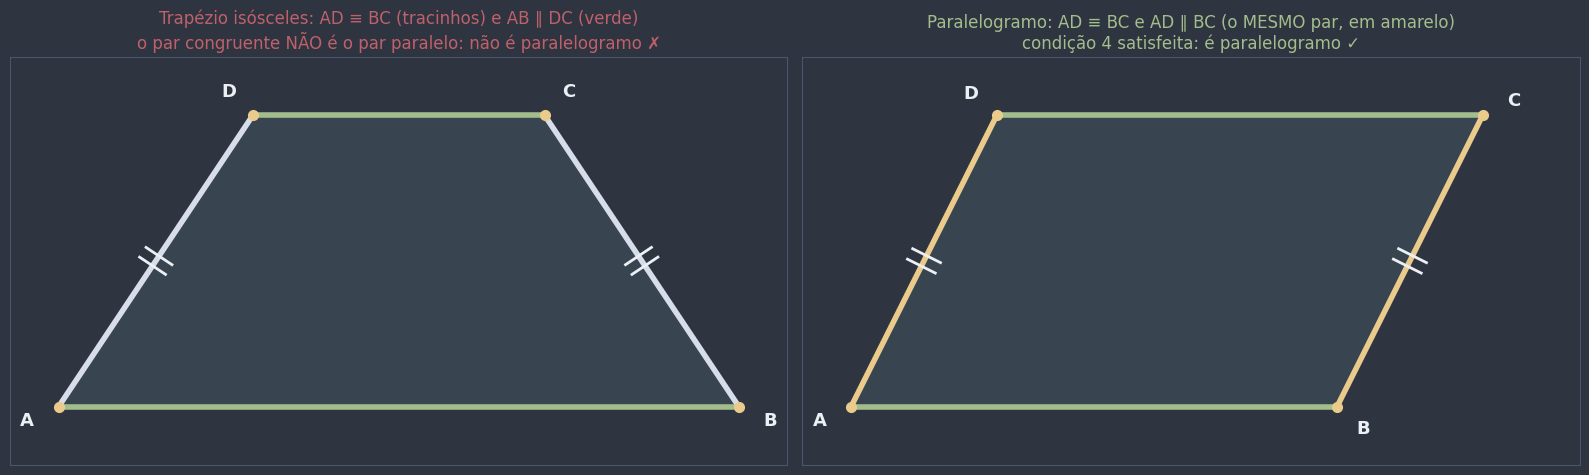

trapézio isósceles: AD = 3.606, BC = 3.606, AB ∥ DC? True, AD ∥ BC? False
pontos médios das diagonais: AC → [2.5 1.5],  BD → [4.5 1.5]  (diferentes!)


In [9]:
trapezio = EXEMPLOS_SECAO_2["trapézio isósceles"]
para = EXEMPLOS_SECAO_2["paralelogramo"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.2))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, vertices, titulo, cor in [
    (ax1, trapezio, "Trapézio isósceles: AD ≡ BC (tracinhos) e AB ∥ DC (verde)\n"
                    "o par congruente NÃO é o par paralelo: não é paralelogramo ✗", COR_ALERTA),
    (ax2, para, "Paralelogramo: AD ≡ BC e AD ∥ BC (o MESMO par, em amarelo)\n"
                "condição 4 satisfeita: é paralelogramo ✓", COR_DESTAQUE),
]:
    A, B, C, D = vertices
    preparar_eixo(ax, [(-0.5, -0.6), (7.5, 3.6)], margem=0)
    ax.add_patch(Polygon(vertices, closed=True, facecolor=COR_PONTO, alpha=0.12, edgecolor="none"))
    cor_AB = COR_DESTAQUE if sao_paralelos(A, B, D, C) else NORD_TEXTO_SEC
    cor_AD = COR_AVISO if sao_paralelos(A, D, B, C) else NORD_TEXTO_SEC
    for P, Q, c in ((A, B, cor_AB), (D, C, cor_AB), (A, D, cor_AD), (B, C, cor_AD)):
        ax.plot(*zip(P, Q), color=c, lw=4)
    marcar_congruentes(ax, A, D, 2)
    marcar_congruentes(ax, B, C, 2)
    rotular_vertices(ax, vertices, distancia=0.35)
    ax.set_title(titulo, color=cor, fontsize=12)
plt.tight_layout()
plt.show()

A, B, C, D = trapezio
print(f"trapézio isósceles: AD = {math.dist(A, D):.3f}, BC = {math.dist(B, C):.3f}, AB ∥ DC? {sao_paralelos(A, B, D, C)}, "
      f"AD ∥ BC? {sao_paralelos(A, D, B, C)}")
print(f"pontos médios das diagonais: AC → {ponto_medio(A, C)},  BD → {ponto_medio(B, D)}  (diferentes!)")

🕹️ **Widget interativo:** os vértices $A$, $B$ e $C$ estão fixos; os sliders `x de D` e `y de D` movem o quarto vértice. Os pontos médios das duas diagonais aparecem em amarelo (de $\overline{AC}$) e em lilás (de $\overline{BD}$), e o painel confere as quatro condições. Procure a posição de $D$ em que os dois pontos médios **se encontram**: repare que, nesse instante, as **quatro** condições acendem juntas.

In [ ]:
def explorar_condicoes(x_D: float, y_D: float) -> None:
    A, B, C = np.array([0.0, 0.0]), np.array([5.0, 0.0]), np.array([6.5, 3.0])
    D = np.array([x_D, y_D])
    vertices = [A, B, C, D]
    tipo = tipo_de_quadrilatero(vertices)
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14.5, 5.4), gridspec_kw={"width_ratios": [1.45, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1.5, -0.8), (7.3, 5.6)], margem=0)
    if tipo != "convexo":
        desenhar_quadrilatero(ax, vertices, cor=COR_ALERTA, largura=3, preencher=False)
        rotular_vertices(ax, vertices, distancia=0.4)
        ax.set_title(f"Quadrilátero {tipo}: as condições só valem para quadriláteros convexos.\nMova D de volta.",
                     color=COR_ALERTA, fontsize=13)
        escrever_checklist(ax_lista, [])
    else:
        testes = eh_paralelogramo(A, B, C, D)
        cor = COR_DESTAQUE if testes["definição (2 pares ∥)"] else COR_PONTO
        desenhar_quadrilatero(ax, vertices, cor=cor, largura=3)
        ax.plot(*zip(A, C), color=COR_AVISO, lw=1.6, linestyle="--")
        ax.plot(*zip(B, D), color=COR_EXTRA, lw=1.6, linestyle="--")
        meio_AC, meio_BD = ponto_medio(A, C), ponto_medio(B, D)
        ax.plot(*meio_AC, "o", color=COR_AVISO, markersize=11, zorder=6)
        ax.plot(*meio_BD, "o", color=COR_EXTRA, markersize=7, zorder=7)
        rotular_vertices(ax, vertices, distancia=0.4)
        distancia_meios = math.dist(meio_AC, meio_BD)
        escrever_checklist(ax_lista, list(testes.items()), "Condições (seção 2)")
        if testes["definição (2 pares ∥)"]:
            titulo = "Os pontos médios das diagonais coincidem: ABCD é PARALELOGRAMO!"
        else:
            titulo = f"Pontos médios das diagonais afastados {distancia_meios:.2f}: não é paralelogramo"
        ax.set_title(titulo, color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_condicoes,
    x_D=widgets.FloatSlider(value=2.5, min=-1, max=4, step=0.25, description="x de D:"),
    y_D=widgets.FloatSlider(value=4.0, min=1, max=5, step=0.25, description="y de D:"),
);

interactive(children=(FloatSlider(value=2.5, description='x de D:', max=4.0, min=-1.0, step=0.25), FloatSlider…

**Pergunta de checagem:** um quadrilátero tem dois lados opostos congruentes e os outros dois lados opostos paralelos. Ele é necessariamente um paralelogramo?

**Pergunta de checagem:** as diagonais de um quadrilátero medem 10 cm e 6 cm e se cortam ao meio. Ele é um paralelogramo? Pode ser um retângulo? (Guarde a segunda resposta para conferir na próxima seção.)

## 3. Retângulo

📌 **Definição formal (retângulo):** **retângulo** é o quadrilátero que tem os **quatro ângulos retos**. De forma equivalente: retângulo é o **paralelogramo com um ângulo reto**.

Por que as duas definições dizem a mesma coisa? Nos dois sentidos:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | quatro ângulos retos ⇒ paralelogramo | os ângulos opostos são congruentes (todos medem 90°): condição 2 da seção 2 |
| 2 | paralelogramo com $\hat{A} = 90^\circ$ ⇒ $\hat{B} = 90^\circ$ | ângulos consecutivos suplementares: $\hat{B} = 180^\circ - 90^\circ$ (propriedade 3) |
| 3 | $\hat{C} = \hat{A} = 90^\circ$ e $\hat{D} = \hat{B} = 90^\circ$ | ângulos opostos congruentes (propriedade 2) ∎ |

Como é um paralelogramo, o retângulo herda **todas** as propriedades da seção 1. Mas tem uma que é **só dele**, aquela que se perdeu quando ele tombou no gancho:

📌 **Teorema (diagonais do retângulo):** as diagonais de um retângulo são **congruentes**: $AC = BD$.

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $AB = DC$ | lados opostos do paralelogramo (seção 1) |
| 2 | $A\hat{B}C = D\hat{C}B = 90^\circ$ | ângulos do retângulo |
| 3 | $\overline{BC}$ é comum | lado comum aos dois triângulos |
| 4 | $\triangle ABC \equiv \triangle DCB$ | caso LAL: passos 1, 2 e 3 (0405a) |
| 5 | $AC = DB$ | lados correspondentes de triângulos congruentes ∎ |

📌 **Recíproca:** um **paralelogramo** com diagonais congruentes é um retângulo. Com $AC = DB$, os mesmos triângulos ficam congruentes por **LLL** ($AB = DC$, $\overline{BC}$ comum e $AC = DB$), então $\hat{B} = \hat{C}$. Como $\hat{B}$ e $\hat{C}$ são consecutivos, $\hat{B} + \hat{C} = 180^\circ$, e cada um mede 90°.

**Uma consequência bonita:** as diagonais do retângulo se cortam ao meio (paralelogramo) **e** são congruentes. Então as quatro metades são iguais: $MA = MB = MC = MD$. O ponto $M$ está à mesma distância dos quatro vértices, ou seja, existe uma circunferência de centro $M$ que passa pelos quatro cantos do retângulo. Essa ideia de "quadrilátero inscrito numa circunferência" volta em 📌 Circunferência e Círculo.

**A representação numérica**, num retângulo "girado" (com os lados inclinados, para não depender de lados horizontais):

In [11]:
retangulo = paralelogramo_por_lados(4, 2.5, 90, inclinacao=25)
A, B, C, D = retangulo
M = cruzamento(A, direcao_de(A, C), B, direcao_de(B, D))

display(pd.DataFrame([{f"ângulo {nome}": f"{a:.4f}°"
                       for nome, a in zip("ABCD", angulos_internos(retangulo))}]).style.hide(axis="index"))
display(pd.DataFrame([
    {"segmento": "diagonal AC", "medida": f"{math.dist(A, C):.4f}"},
    {"segmento": "diagonal BD", "medida": f"{math.dist(B, D):.4f}"},
    {"segmento": "MA", "medida": f"{math.dist(M, A):.4f}"},
    {"segmento": "MB", "medida": f"{math.dist(M, B):.4f}"},
    {"segmento": "MC", "medida": f"{math.dist(M, C):.4f}"},
    {"segmento": "MD", "medida": f"{math.dist(M, D):.4f}"},
]).style.hide(axis="index"))
print(f"AC = BD? {iguais(math.dist(A, C), math.dist(B, D))}   |   "
      f"M equidistante dos 4 vértices? {all(iguais(math.dist(M, V), math.dist(M, A)) for V in retangulo)}")

ângulo A,ângulo B,ângulo C,ângulo D
90.0000°,90.0000°,90.0000°,90.0000°


segmento,medida
diagonal AC,4.7170
diagonal BD,4.7170
MA,2.3585
MB,2.3585
MC,2.3585
MD,2.3585


AC = BD? True   |   M equidistante dos 4 vértices? True


A representação gráfica: as quatro metades das diagonais com o mesmo tracinho, e a circunferência de centro $M$ passando pelos quatro vértices.

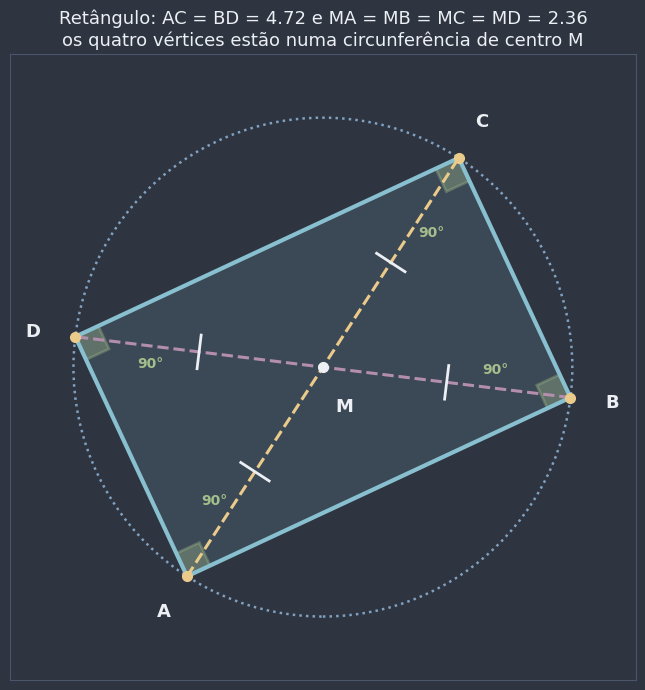

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 7))
fig.patch.set_facecolor(NORD_FUNDO)
raio = math.dist(M, A)
preparar_eixo(ax, [M - raio, M + raio], margem=0.6)
ax.add_patch(Circle(M, raio, fill=False, edgecolor=COR_SECUNDARIA, lw=1.8, linestyle=":"))
desenhar_quadrilatero(ax, retangulo, cor=COR_PONTO, largura=3)
desenhar_angulos_internos(ax, retangulo, raio=0.4, tamanho_fonte=10)
desenhar_diagonais(ax, retangulo)
for V in retangulo:
    marcar_congruentes(ax, M, V, 1)
rotular_vertices(ax, retangulo, distancia=0.4)
ax.set_title(f"Retângulo: AC = BD = {math.dist(A, C):.2f} e MA = MB = MC = MD = {raio:.2f}\n"
             "os quatro vértices estão numa circunferência de centro M", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** os sliders `largura` e `altura` definem um retângulo (à esquerda). À direita, as **mesmas** quatro varetas tombadas pelo slider `tombo`. Compare os comprimentos das diagonais nos dois lados: no retângulo, $AC = BD$ sempre, para qualquer largura e altura; no paralelogramo tombado, a diagonal amarela estica e a lilás encolhe. Leve o `tombo` a 0° para ver os dois lados ficarem iguais.

In [ ]:
def explorar_retangulo(largura: float, altura: float, tombo: int) -> None:
    fig, eixos = plt.subplots(1, 2, figsize=(15, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    figuras = [(eixos[0], paralelogramo_por_lados(largura, altura, 90), "Retângulo"),
               (eixos[1], paralelogramo_por_lados(largura, altura, 90 - tombo), f"Tombado {tombo}°")]
    for ax, vertices, nome in figuras:
        A, B, C, D = vertices
        preparar_eixo(ax, [(-0.8, -0.8), (9.8, 4.8)], margem=0)
        desenhar_quadrilatero(ax, vertices, cor=COR_PONTO, largura=3)
        desenhar_angulos_internos(ax, vertices, raio=0.35, tamanho_fonte=9)
        desenhar_diagonais(ax, vertices)
        rotular_vertices(ax, vertices, distancia=0.35)
        ac, bd = math.dist(A, C), math.dist(B, D)
        sinal = "=" if iguais(ac, bd) else "≠"
        ax.set_title(f"{nome}: AC = {ac:.2f} {sinal} BD = {bd:.2f}", color=COR_DESTAQUE if sinal == "=" else COR_ALERTA,
                     fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_retangulo,
    largura=widgets.FloatSlider(value=4.5, min=2, max=6, step=0.5, description="largura:"),
    altura=widgets.FloatSlider(value=3, min=1, max=4, step=0.5, description="altura:"),
    tombo=widgets.IntSlider(value=25, min=0, max=60, step=5, description="tombo (°):"),
);

interactive(children=(FloatSlider(value=4.5, description='largura:', max=6.0, min=2.0, step=0.5), FloatSlider(…

🎯 **Aplicação prática — o "esquadro pelas diagonais":** como um pedreiro confere se a fundação de uma casa, um piso ou uma laje retangular está **no esquadro** (com os cantos retos)? Medir ângulos com transferidor numa obra é impreciso. O truque é usar só a trena, em duas etapas:

1. conferir que os **lados opostos são iguais**, o que garante um **paralelogramo** (condição 1 da seção 2);
2. medir as **duas diagonais**: se forem iguais, o paralelogramo é um **retângulo** (a recíproca acima).

A ordem importa: a recíproca vale para **paralelogramos**. Diagonais iguais sozinhas não bastam (o trapézio isósceles tem diagonais congruentes, como você vai conferir na pergunta de checagem abaixo). A função `conferir_esquadro` faz o diagnóstico, com uma tolerância de 1 cm nas medidas.

In [14]:
def conferir_esquadro(frente: float, fundo: float, lado_esq: float, lado_dir: float,
                      diagonal_1: float, diagonal_2: float, tolerancia: float = 0.01) -> str:
    """Diagnóstico de uma marcação retangular feita com trena (medidas em metros)."""
    if abs(frente - fundo) > tolerancia or abs(lado_esq - lado_dir) > tolerancia:
        return "❌ lados opostos diferentes: nem paralelogramo é (refazer a marcação)"
    if abs(diagonal_1 - diagonal_2) <= tolerancia:
        return "✅ paralelogramo com diagonais iguais: retângulo, está no esquadro"
    return f"⚠️ paralelogramo fora do esquadro: as diagonais diferem {100 * abs(diagonal_1 - diagonal_2):.0f} cm"


obras = {
    "fundação da casa": (10, 10, 6, 6, 11.66, 11.66),
    "piso da garagem": (10, 10, 6, 6, 12.10, 11.20),
    "laje da varanda": (8, 8, 5, 5, 9.43, 9.43),
    "quadra de areia": (16, 15.8, 8, 8, 17.89, 17.89),
}
display(pd.DataFrame([
    {"obra": nome, "frente × fundo (m)": f"{m[0]:g} × {m[1]:g}", "laterais (m)": f"{m[2]:g} e {m[3]:g}",
     "diagonais (m)": f"{m[4]:g} e {m[5]:g}", "diagnóstico": conferir_esquadro(*m)}
    for nome, m in obras.items()
]).style.hide(axis="index"))

obra,frente × fundo (m),laterais (m),diagonais (m),diagnóstico
fundação da casa,10 × 10,6 e 6,11.66 e 11.66,"✅ paralelogramo com diagonais iguais: retângulo, está no esquadro"
piso da garagem,10 × 10,6 e 6,12.1 e 11.2,⚠️ paralelogramo fora do esquadro: as diagonais diferem 90 cm
laje da varanda,8 × 8,5 e 5,9.43 e 9.43,"✅ paralelogramo com diagonais iguais: retângulo, está no esquadro"
quadra de areia,16 × 15.8,8 e 8,17.89 e 17.89,❌ lados opostos diferentes: nem paralelogramo é (refazer a marcação)


📖 **Leitura complementar:** [Retângulo](https://pt.wikipedia.org/wiki/Ret%C3%A2ngulo)

**Pergunta de checagem:** se as diagonais de um paralelogramo medem 12 cm e 12 cm, o que se pode concluir sobre ele?

**Pergunta de checagem:** um quadrilátero tem as diagonais congruentes. Ele é necessariamente um retângulo? (Dica: confira as diagonais do trapézio isósceles da seção 2.)

## 4. Losango

📌 **Definição formal (losango):** **losango** é o quadrilátero que tem os **quatro lados congruentes**.

Todo losango é paralelogramo: com quatro lados iguais, os lados opostos são congruentes, e a condição 1 da seção 2 resolve. De forma equivalente, losango é o **paralelogramo com dois lados consecutivos congruentes** (se $AB = BC$, os lados opostos completam o resto: $CD = AB$ e $DA = BC$).

Além de tudo o que herda do paralelogramo, o losango tem uma propriedade **só dele**, agora sobre a **posição** das diagonais (e não sobre o tamanho delas):

📌 **Teorema (diagonais do losango):** as diagonais de um losango são **perpendiculares** entre si e são **bissetrizes** dos ângulos internos.

Seja $M$ o ponto em que as diagonais se cruzam:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $AM = MC$ | as diagonais do paralelogramo se cortam ao meio (seção 1) |
| 2 | $BA = BC$ | lados do losango |
| 3 | $\overline{BM}$ é comum | lado comum aos dois triângulos |
| 4 | $\triangle ABM \equiv \triangle CBM$ | caso LLL: passos 1, 2 e 3 (0405a) |
| 5 | $A\hat{M}B \equiv C\hat{M}B$, e como eles somam $180^\circ$, cada um mede $90^\circ$ | ângulos correspondentes; $A\hat{M}B$ e $C\hat{M}B$ formam o ângulo raso $A\hat{M}C$: logo $\overline{AC} \perp \overline{BD}$ |
| 6 | $A\hat{B}M \equiv C\hat{B}M$ | ângulos correspondentes: $\overline{BD}$ é **bissetriz** de $\hat{B}$ |
| 7 | o mesmo vale em $D$, em $A$ e em $C$ | mesma ideia com $\triangle ADM \equiv \triangle CDM$ e com $\triangle BAM \equiv \triangle DAM$ ∎ |

Outro jeito de ver o mesmo resultado: o triângulo $ABC$ é **isósceles** de base $\overline{AC}$, e $\overline{BM}$ é a **mediana** relativa à base. Em [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) você viu que, no isósceles, essa mediana também é **altura** e **bissetriz**: é exatamente o que os passos 5 e 6 dizem.

📎 **Conexão — cada diagonal é a mediatriz da outra:** em [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb), a mediatriz de $\overline{AC}$ foi descrita como o **lugar geométrico** dos pontos equidistantes de $A$ e de $C$. No losango, $BA = BC$ e $DA = DC$: tanto $B$ quanto $D$ estão à mesma distância de $A$ e de $C$, então os dois estão na mediatriz de $\overline{AC}$. Dois pontos determinam uma reta, e por isso a reta $\overleftrightarrow{BD}$ **é** a mediatriz de $\overline{AC}$. Com o mesmo argumento ($AB = AD$ e $CB = CD$), $\overleftrightarrow{AC}$ é a mediatriz de $\overline{BD}$.

**A representação numérica.** Para conferir que as diagonais são perpendiculares, usamos o **produto escalar** dos vetores $\overrightarrow{AC}$ e $\overrightarrow{BD}$: $\;u_x v_x + u_y v_y$. Ele é a conta que está dentro do transferidor digital `medir_angulo` (o "cosseno"), e dá **zero** exatamente quando os dois vetores são perpendiculares. Os detalhes ficam para 📌 Geometria Analítica; aqui, basta saber ler o zero.

In [15]:
losango = losango_por_diagonais(8, 5, giro=20)
A, B, C, D = losango
M = cruzamento(A, direcao_de(A, C), B, direcao_de(B, D))
AC, BD = C - A, D - B

display(pd.DataFrame([{f"lado {lado}": f"{math.dist(P, Q):.4f}"
                       for lado, P, Q in (("AB", A, B), ("BC", B, C), ("CD", C, D), ("DA", D, A))}]).style.hide(axis="index"))
print(f"diagonais: AC = {math.dist(A, C):.4f} e BD = {math.dist(B, D):.4f}")
print(f"produto escalar AC · BD = {AC[0]:.3f} × {BD[0]:.3f} + {AC[1]:.3f} × {BD[1]:.3f} = {np.dot(AC, BD):.10f}")
print(f"ângulo entre as diagonais (transferidor em M): {medir_angulo(M, A, B):.4f}°\n")

display(pd.DataFrame([
    {"vértice": "A", "ângulo interno": f"{medir_angulo(A, B, D):.3f}°", "metade 1": f"BÂC = {medir_angulo(A, B, C):.3f}°",
     "metade 2": f"CÂD = {medir_angulo(A, C, D):.3f}°"},
    {"vértice": "B", "ângulo interno": f"{medir_angulo(B, A, C):.3f}°", "metade 1": f"AB̂D = {medir_angulo(B, A, D):.3f}°",
     "metade 2": f"DB̂C = {medir_angulo(B, D, C):.3f}°"},
    {"vértice": "C", "ângulo interno": f"{medir_angulo(C, B, D):.3f}°", "metade 1": f"BĈA = {medir_angulo(C, B, A):.3f}°",
     "metade 2": f"AĈD = {medir_angulo(C, A, D):.3f}°"},
    {"vértice": "D", "ângulo interno": f"{medir_angulo(D, A, C):.3f}°", "metade 1": f"AD̂B = {medir_angulo(D, A, B):.3f}°",
     "metade 2": f"BD̂C = {medir_angulo(D, B, C):.3f}°"},
]).style.hide(axis="index"))

lado AB,lado BC,lado CD,lado DA
4.7170,4.7170,4.7170,4.7170


diagonais: AC = 8.0000 e BD = 5.0000
produto escalar AC · BD = 7.518 × -1.710 + 2.736 × 4.698 = 0.0000000000
ângulo entre as diagonais (transferidor em M): 90.0000°



vértice,ângulo interno,metade 1,metade 2
A,64.011°,BÂC = 32.005°,CÂD = 32.005°
B,115.989°,AB̂D = 57.995°,DB̂C = 57.995°
C,64.011°,BĈA = 32.005°,AĈD = 32.005°
D,115.989°,AD̂B = 57.995°,BD̂C = 57.995°


Os quatro lados iguais, o produto escalar zero (a menos de um arredondamento minúsculo do computador), o ângulo de 90° em $M$, e cada ângulo interno dividido em duas metades iguais pela diagonal que passa por ele. Agora a representação gráfica: as metades de cada ângulo têm a mesma cor, e a diagonal $\overline{BD}$ aparece como a mediatriz de $\overline{AC}$.

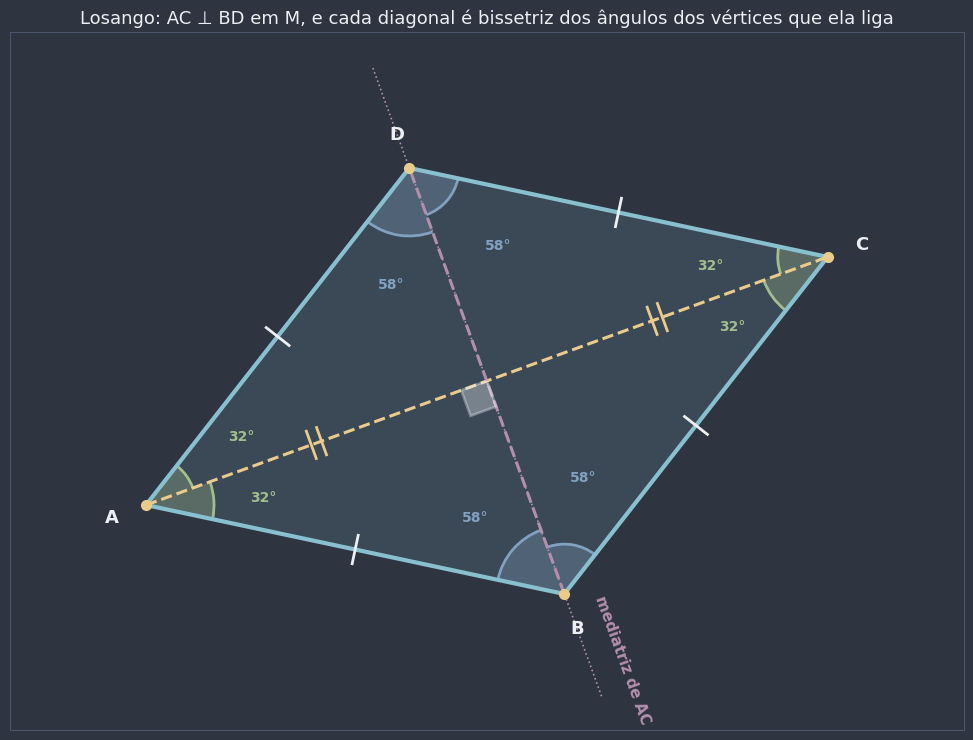

In [16]:
fig, ax = plt.subplots(figsize=(10, 7.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, losango, margem=1.5)
desenhar_quadrilatero(ax, losango, cor=COR_PONTO, largura=3)
for P, Q in ((A, B), (B, C), (C, D), (D, A)):
    marcar_congruentes(ax, P, Q, 1)
desenhar_diagonais(ax, losango, nome_meio="")
marcar_angulo_reto(ax, M, A, B, tamanho=0.3, cor=NORD_TEXTO)
for vertice, P, Q, cor in [(A, B, D, COR_DESTAQUE), (C, B, D, COR_DESTAQUE), (B, A, C, COR_SECUNDARIA),
                           (D, A, C, COR_SECUNDARIA)]:
    meio = ponto_medio(A, C) if vertice is B or vertice is D else ponto_medio(B, D)
    for X, Y, raio_arco in ((P, meio, 0.75), (meio, Q, 0.55)):  # as duas metades do ângulo, separadas
        desenhar_arco(ax, vertice, X, Y, raio=raio_arco, cor=cor, rotulo=f"{medir_angulo(vertice, X, Y):.0f}°",
                      raio_rotulo=1.3, tamanho_fonte=10)
for P, Q in ((A, M), (M, C)):
    marcar_congruentes(ax, P, Q, 2, cor=COR_AVISO)
rotular_vertices(ax, losango, distancia=0.4)
# A mediatriz é uma RETA: prolongamos BD para fora do losango e escrevemos o nome no prolongamento
u_BD = direcao(direcao_de(B, D))
ax.plot(*zip(B - 1.2 * u_BD, D + 1.2 * u_BD), color=COR_EXTRA, lw=1.2, linestyle=":")
inclinacao_BD = (direcao_de(B, D) + 90) % 180 - 90  # entre −90° e 90°, para o texto não ficar de ponta-cabeça
ax.text(*(B - 0.9 * u_BD + 0.35 * direcao(inclinacao_BD + 90)), "mediatriz de AC", color=COR_EXTRA,
        fontsize=11, fontweight="bold", rotation=inclinacao_BD, ha="center", va="center")
ax.set_title("Losango: AC ⊥ BD em M, e cada diagonal é bissetriz dos ângulos dos vértices que ela liga",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** achar que "quatro lados iguais" garante "quatro ângulos iguais". Não garante! O losango genérico tem dois ângulos agudos e dois obtusos (opostos iguais, consecutivos suplementares). Quatro lados iguais **e** quatro ângulos iguais (retos) é o **quadrado**, o caso especial da seção 5.

🕹️ **Widget interativo:** aqui o losango é construído **a partir das diagonais**: os sliders `diagonal AC` ($d_1$) e `diagonal BD` ($d_2$) definem os comprimentos, e as diagonais são traçadas perpendiculares e cortando-se ao meio. Isso basta para determinar o losango inteiro: repare que os quatro lados saem sempre iguais. Procure o caso $d_1 = d_2$: o que acontece com os ângulos?

In [17]:
def explorar_losango(d1: float, d2: float) -> None:
    vertices = losango_por_diagonais(d1, d2)
    A, B, C, D = vertices
    propriedades = {
        f"quatro lados ≡ (lado = {math.dist(A, B):.2f})": all(
            iguais(math.dist(vertices[k], vertices[(k + 1) % 4]), math.dist(A, B)) for k in range(4)),
        "diagonais ⊥ (produto escalar = 0)": iguais(np.dot(C - A, D - B), 0),
        "diagonais bissetrizes": iguais(medir_angulo(A, B, C), medir_angulo(A, C, D))
        and iguais(medir_angulo(B, A, D), medir_angulo(B, D, C)),
        f"diagonais ≡ (d1 = {d1:g}, d2 = {d2:g})": iguais(d1, d2),
        "quatro ângulos retos": all(iguais(a, 90) for a in angulos_internos(vertices)),
    }
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.2, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-5.6, -5.6), (5.6, 5.6)], margem=0)
    quadrado = iguais(d1, d2)
    cor = NORD_TEXTO if quadrado else COR_EXTRA
    desenhar_quadrilatero(ax, vertices, cor=cor, largura=3)
    for vertice, anterior, proximo, cor_angulo in ((A, D, B, COR_DESTAQUE), (B, A, C, COR_SECUNDARIA),
                                                    (C, B, D, COR_DESTAQUE), (D, C, A, COR_SECUNDARIA)):
        desenhar_arco(ax, vertice, anterior, proximo, raio=0.55, cor=cor_angulo)
    desenhar_diagonais(ax, vertices, nome_meio="")
    marcar_angulo_reto(ax, np.zeros(2), A, B, tamanho=0.3, cor=NORD_TEXTO)
    rotular_vertices(ax, vertices, distancia=0.45)
    escrever_checklist(ax_lista, list(propriedades.items()), "O que vale neste losango?")
    a_A, a_B = medir_angulo(A, B, D), medir_angulo(B, A, C)
    titulo = ("d1 = d2: o losango virou QUADRADO (ângulos de 90°)" if quadrado
              else f"Losango de diagonais {d1:g} e {d2:g}")
    ax.set_title(f"{titulo}\nÂ = Ĉ = {a_A:.1f}° (verdes)   B̂ = D̂ = {a_B:.1f}° (azuis)", color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_losango,
    d1=widgets.FloatSlider(value=8, min=1, max=10, step=0.5, description="diagonal AC:"),
    d2=widgets.FloatSlider(value=5, min=1, max=10, step=0.5, description="diagonal BD:"),
);

interactive(children=(FloatSlider(value=8.0, description='diagonal AC:', max=10.0, min=1.0, step=0.5), FloatSl…

🎯 **Aplicação prática — design, sinalização e estruturas:** o losango é uma das formas preferidas em padrões decorativos: o "padrão arlequim" de ladrilhos, tecidos e vitrais, o naipe de **ouros** do baralho, malhas de alambrado e treliças. Nas treliças e nos alambrados, a propriedade das diagonais é o que importa: os arames se cruzam formando losangos, e as diagonais perpendiculares dividem cada losango em quatro triângulos retângulos congruentes, o que distribui os esforços por igual. E a placa amarela de **advertência** do trânsito, que todo mundo chama de "losango"? Ela é um **quadrado** girado 45°... e, na convenção inclusiva, os dois nomes estão certos (seção 5).

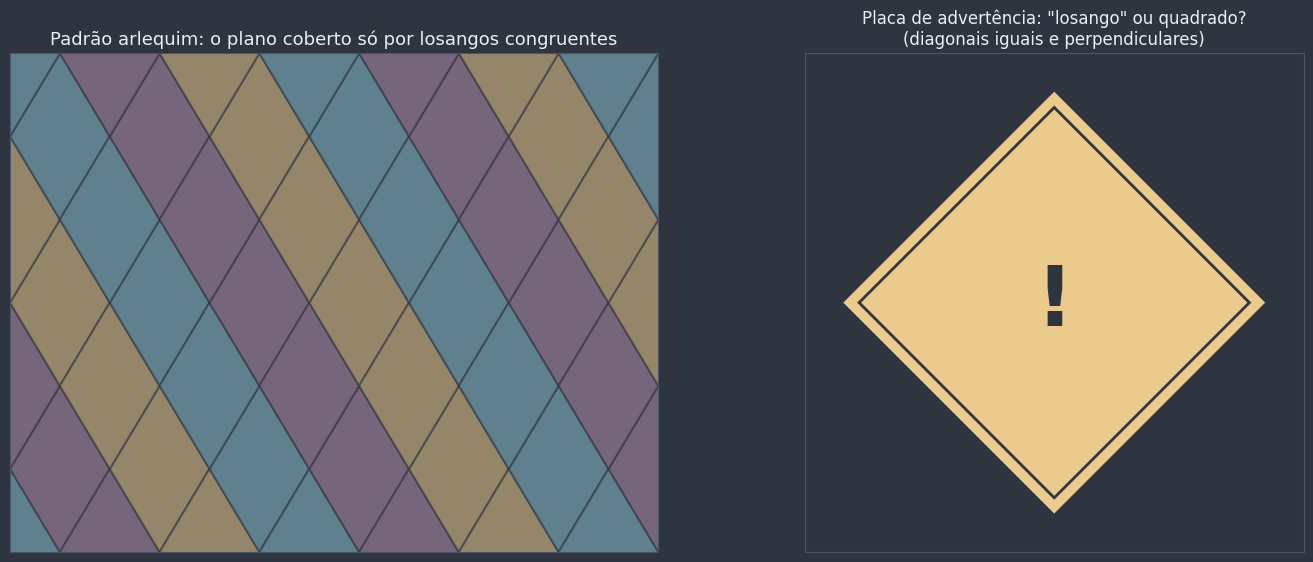

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.6), gridspec_kw={"width_ratios": [1.6, 1]})
fig.patch.set_facecolor(NORD_FUNDO)

# Padrão arlequim: losangos de diagonais 1,2 (horizontal) e 2 (vertical), lado a lado
preparar_eixo(ax1, [(0.6, 1.0), (8.4, 7.0)], margem=0)
cores = [COR_PONTO, COR_EXTRA, COR_AVISO]
for i in range(8):
    for j in range(4):
        for deslocamento, desvio in ((np.array([0.0, 0.0]), 0), (np.array([0.6, 1.0]), 1)):
            centro = np.array([0.6 + 1.2 * i, 1.0 + 2.0 * j]) + deslocamento
            ladrilho = losango_por_diagonais(1.2, 2.0, centro=centro)
            ax1.add_patch(Polygon(ladrilho, closed=True, facecolor=cores[(i + j + desvio) % 3], alpha=0.55,
                                  edgecolor=NORD_FUNDO, lw=1.5))
ax1.set_title("Padrão arlequim: o plano coberto só por losangos congruentes", color=NORD_TEXTO, fontsize=13)

# Placa de advertência: um quadrado girado 45°
preparar_eixo(ax2, [(-2.2, -2.2), (2.2, 2.2)], margem=0.1)
placa = losango_por_diagonais(4, 4)
ax2.add_patch(Polygon(placa, closed=True, facecolor=COR_AVISO, edgecolor=NORD_FUNDO, lw=6))
ax2.add_patch(Polygon(losango_por_diagonais(3.6, 3.6), closed=True, fill=False, edgecolor=NORD_FUNDO, lw=2))
ax2.text(0, 0, "!", color=NORD_FUNDO, fontsize=60, fontweight="bold", ha="center", va="center")
ax2.set_title("Placa de advertência: \"losango\" ou quadrado?\n(diagonais iguais e perpendiculares)",
              color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

📖 **Leitura complementar:** [Losango](https://pt.wikipedia.org/wiki/Losango)

**Pergunta de checagem:** por que as diagonais de um losango são perpendiculares? Dica: pense em triângulos isósceles e na mediatriz.

**Pergunta de checagem:** um losango tem um ângulo de 70°. Quanto medem os ângulos que a diagonal que sai desse vértice forma com os dois lados?

## 5. Quadrado e a hierarquia completa

📌 **Definição formal (quadrado):** **quadrado** é o quadrilátero que tem os **quatro lados congruentes** e os **quatro ângulos retos**. Ou seja, é ao mesmo tempo **retângulo** (quatro ângulos retos) **e losango** (quatro lados congruentes).

Por estar na interseção, o quadrado **herda tudo**:
- do **paralelogramo**: lados e ângulos opostos congruentes, ângulos consecutivos suplementares, diagonais que se cortam ao meio;
- do **retângulo**: diagonais **congruentes**;
- do **losango**: diagonais **perpendiculares** e **bissetrizes** dos ângulos internos.

Juntando as três: as diagonais do quadrado **se cortam ao meio, são congruentes e são perpendiculares**. E como cada diagonal é bissetriz de um ângulo de 90°, ela forma ângulos de **45°** com os lados.

**A hierarquia completa.** Agora dá para completar o mapa de [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) com as propriedades de cada nível:

$$\text{quadrilátero} \supset \text{trapézio} \supset \text{paralelogramo} \supset \{\text{retângulo},\ \text{losango}\} \supset \text{quadrado}$$

A regra de ouro é que as propriedades **descem** pela hierarquia: o que vale para um nível vale para todos os que estão abaixo dele. Uma propriedade do paralelogramo vale para retângulo, losango e quadrado; uma do retângulo vale para o quadrado, mas **não** para o losango (que está num "galho" diferente).

| Propriedade | Paralelogramo | Retângulo | Losango | Quadrado |
|---|:---:|:---:|:---:|:---:|
| lados opostos paralelos | ✅ | ✅ | ✅ | ✅ |
| lados opostos congruentes | ✅ | ✅ | ✅ | ✅ |
| ângulos opostos congruentes | ✅ | ✅ | ✅ | ✅ |
| ângulos consecutivos suplementares | ✅ | ✅ | ✅ | ✅ |
| diagonais se cortam ao meio | ✅ | ✅ | ✅ | ✅ |
| quatro ângulos retos | ❌ | ✅ | ❌ | ✅ |
| diagonais congruentes | ❌ | ✅ | ❌ | ✅ |
| quatro lados congruentes | ❌ | ❌ | ✅ | ✅ |
| diagonais perpendiculares | ❌ | ❌ | ✅ | ✅ |
| diagonais bissetrizes dos ângulos | ❌ | ❌ | ✅ | ✅ |

(Os ❌ querem dizer "não vale **sempre**": um paralelogramo **pode** ter diagonais congruentes, mas aí ele já é um retângulo.)

**No código**, a função `classificar_quadrilatero` recebe quatro pontos e devolve a lista de **todas** as categorias às quais o quadrilátero pertence, de cima para baixo na hierarquia. Ela usa a função `testar_propriedades`, que mede as dez propriedades da tabela acima de uma vez.

In [19]:
def testar_propriedades(vertices) -> dict[str, bool]:
    """Mede, no quadrilátero ABCD, as dez propriedades da tabela da seção 5."""
    A, B, C, D = vertices
    lados = [math.dist(vertices[k], vertices[(k + 1) % 4]) for k in range(4)]
    angulos = angulos_internos(vertices)
    return {
        "lados opostos paralelos": sao_paralelos(A, B, D, C) and sao_paralelos(B, C, A, D),
        "lados opostos congruentes": iguais(lados[0], lados[2]) and iguais(lados[1], lados[3]),
        "ângulos opostos congruentes": iguais(angulos[0], angulos[2]) and iguais(angulos[1], angulos[3]),
        "ângulos consecutivos suplementares": all(iguais(angulos[k] + angulos[(k + 1) % 4], 180) for k in range(4)),
        "diagonais se cortam ao meio": bool(np.allclose(ponto_medio(A, C), ponto_medio(B, D))),
        "quatro ângulos retos": all(iguais(a, 90) for a in angulos),
        "diagonais congruentes": iguais(math.dist(A, C), math.dist(B, D)),
        "quatro lados congruentes": all(iguais(lado, lados[0]) for lado in lados),
        "diagonais perpendiculares": iguais(float(np.dot(np.subtract(C, A), np.subtract(D, B))), 0),
        "diagonais bissetrizes": (iguais(medir_angulo(A, B, C), medir_angulo(A, C, D))
                                  and iguais(medir_angulo(B, A, D), medir_angulo(B, D, C))
                                  and iguais(medir_angulo(C, B, A), medir_angulo(C, A, D))
                                  and iguais(medir_angulo(D, A, B), medir_angulo(D, B, C))),
    }


def classificar_quadrilatero(A, B, C, D) -> list[str]:
    """Todas as categorias da hierarquia às quais o quadrilátero ABCD pertence (convenção inclusiva).
    Devolve uma lista vazia se os quatro pontos não formam um quadrilátero simples."""
    if tipo_de_quadrilatero([A, B, C, D]) in ("cruzado", "degenerado"):
        return []
    categorias = ["quadrilátero"]
    pares_paralelos = int(sao_paralelos(A, B, D, C)) + int(sao_paralelos(B, C, A, D))
    if pares_paralelos >= 1:
        categorias.append("trapézio")
    if pares_paralelos == 2:
        categorias.append("paralelogramo")
        propriedades = testar_propriedades([A, B, C, D])
        if propriedades["quatro ângulos retos"]:
            categorias.append("retângulo")
        if propriedades["quatro lados congruentes"]:
            categorias.append("losango")
        if propriedades["quatro ângulos retos"] and propriedades["quatro lados congruentes"]:
            categorias.append("quadrado")
    return categorias


def nome_mais_especifico(A, B, C, D) -> str:
    """O nome mais 'apertado' da hierarquia que serve para o quadrilátero ABCD."""
    categorias = classificar_quadrilatero(A, B, C, D)
    return categorias[-1] if categorias else "não é quadrilátero simples"


GALERIA_5 = {
    "quadrado girado": [(1, 0), (4, 1), (3, 4), (0, 3)],
    "retângulo": [(0, 0), (5, 0), (5, 3), (0, 3)],
    "losango": [(0, 2), (3, 0), (6, 2), (3, 4)],
    "paralelogramo": [(0, 0), (5, 0), (6.5, 3), (1.5, 3)],
    "trapézio isósceles": [(0, 0), (7, 0), (5, 3), (2, 3)],
    "pipa": [(0, 2), (2, 0), (6, 2), (2, 4)],
    "côncavo": [(0, 0), (4.4, 1.4), (0.6, 4.2), (1.5, 2.0)],
    "borboleta": [(0, 0), (4, 3), (4, 0), (0, 3)],
}
GALERIA_5 = {nome: [np.array(v, dtype=float) for v in vertices] for nome, vertices in GALERIA_5.items()}

display(pd.DataFrame([
    {"figura": nome, "classificar_quadrilatero": " ⊃ ".join(classificar_quadrilatero(*vertices)) or "—",
     "nº de categorias": len(classificar_quadrilatero(*vertices)),
     "nome mais específico": nome_mais_especifico(*vertices)}
    for nome, vertices in GALERIA_5.items()
]).style.hide(axis="index"))

figura,classificar_quadrilatero,nº de categorias,nome mais específico
quadrado girado,quadrilátero ⊃ trapézio ⊃ paralelogramo ⊃ retângulo ⊃ losango ⊃ quadrado,6,quadrado
retângulo,quadrilátero ⊃ trapézio ⊃ paralelogramo ⊃ retângulo,4,retângulo
losango,quadrilátero ⊃ trapézio ⊃ paralelogramo ⊃ losango,4,losango
paralelogramo,quadrilátero ⊃ trapézio ⊃ paralelogramo,3,paralelogramo
trapézio isósceles,quadrilátero ⊃ trapézio,2,trapézio
pipa,quadrilátero,1,quadrilátero
côncavo,quadrilátero,1,quadrilátero
borboleta,—,0,não é quadrilátero simples


O quadrado ganha **seis** nomes (todos verdadeiros!), e a borboleta, nenhum: ela nem é um quadrilátero simples. O trapézio isósceles e a pipa param no meio do caminho, cada um por um motivo (a pipa nem trapézio é: não tem lados paralelos).

A representação gráfica da hierarquia, com o que **cada nível acrescenta** ao anterior. Siga as setas de cima para baixo: cada figura tem tudo o que está escrito nas caixas acima dela.

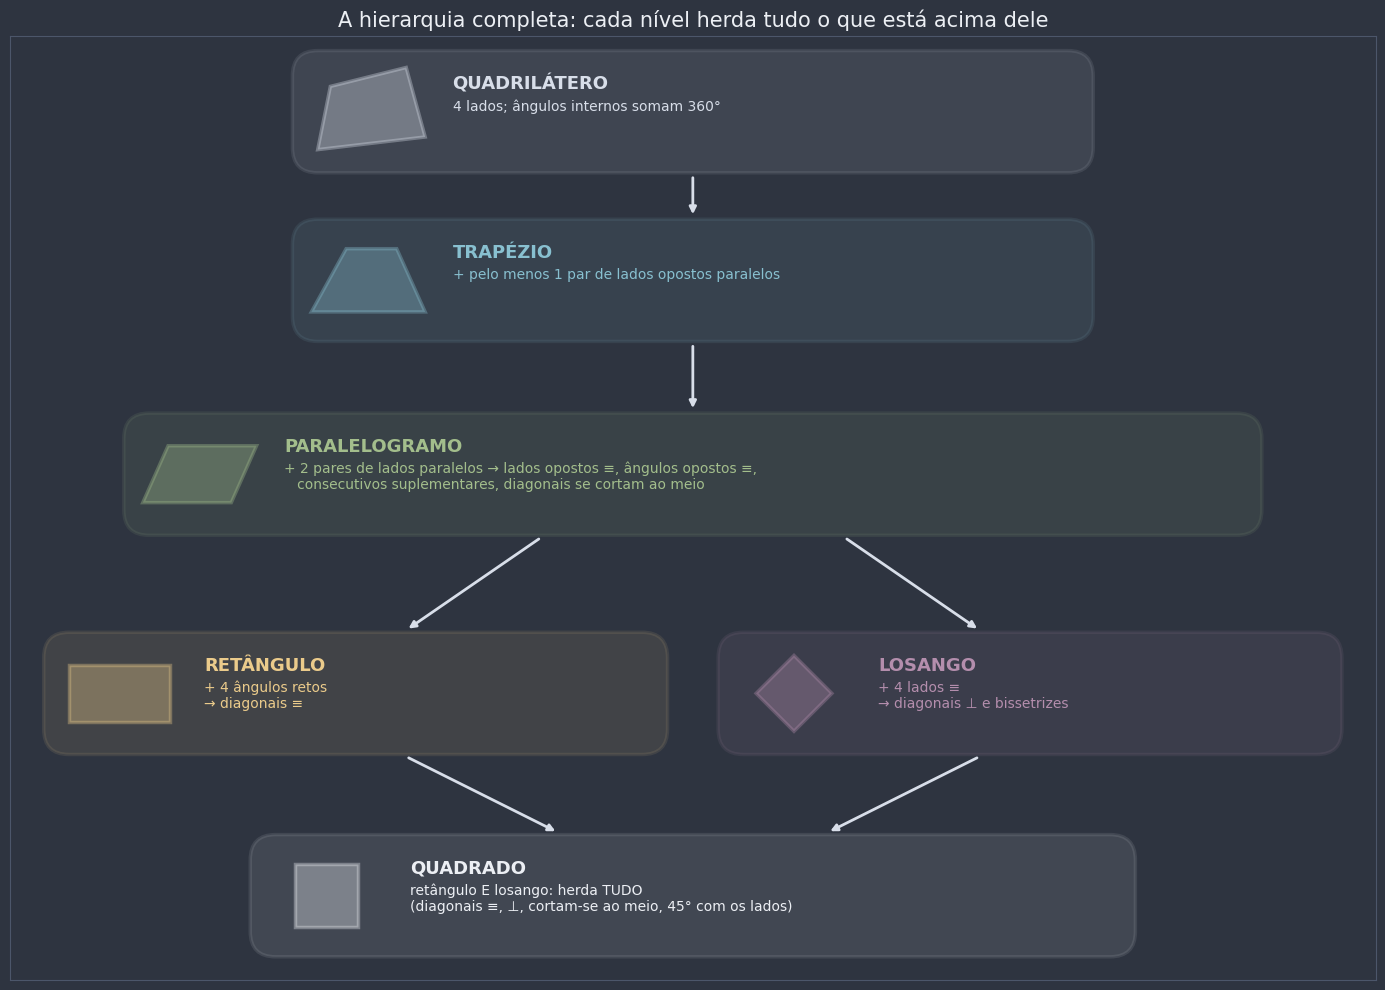

In [20]:
def icone(ax, centro, forma, cor, escala: float = 1.0) -> None:
    """Desenha uma figurinha (lista de vértices em torno de (0, 0)) centrada em `centro`."""
    vertices = [np.asarray(centro) + escala * np.asarray(v) for v in forma]
    ax.add_patch(Polygon(vertices, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2.5, zorder=4))


FORMAS = {
    "quadrilátero": [(-0.8, -0.6), (0.9, -0.4), (0.6, 0.7), (-0.6, 0.4)],
    "trapézio": [(-0.9, -0.5), (0.9, -0.5), (0.45, 0.5), (-0.35, 0.5)],
    "paralelogramo": [(-0.9, -0.45), (0.5, -0.45), (0.9, 0.45), (-0.5, 0.45)],
    "retângulo": [(-0.8, -0.45), (0.8, -0.45), (0.8, 0.45), (-0.8, 0.45)],
    "losango": [(0, -0.6), (0.6, 0), (0, 0.6), (-0.6, 0)],
    "quadrado": [(-0.5, -0.5), (0.5, -0.5), (0.5, 0.5), (-0.5, 0.5)],
}
NIVEIS = [  # (nome, centro da caixa, largura, cor, o que o nível acrescenta)
    ("quadrilátero", (8, 10.2), 9.5, NORD_TEXTO_SEC, "4 lados; ângulos internos somam 360°"),
    ("trapézio", (8, 8.2), 9.5, COR_PONTO, "+ pelo menos 1 par de lados opostos paralelos"),
    ("paralelogramo", (8, 5.9), 13.5, COR_DESTAQUE,
     "+ 2 pares de lados paralelos → lados opostos ≡, ângulos opostos ≡,\n"
     "   consecutivos suplementares, diagonais se cortam ao meio"),
    ("retângulo", (4.0, 3.3), 7.4, COR_AVISO, "+ 4 ângulos retos\n→ diagonais ≡"),
    ("losango", (12.0, 3.3), 7.4, COR_EXTRA, "+ 4 lados ≡\n→ diagonais ⊥ e bissetrizes"),
    ("quadrado", (8, 0.9), 10.5, NORD_TEXTO, "retângulo E losango: herda TUDO\n(diagonais ≡, ⊥, cortam-se ao meio, 45° com os lados)"),
]
ALTURA_CAIXA = 1.45

fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(0, 0), (16, 11)], margem=0.1)
for nome, (cx, cy), largura, cor, texto in NIVEIS:
    ax.add_patch(FancyBboxPatch((cx - largura / 2, cy - ALTURA_CAIXA / 2), largura, ALTURA_CAIXA,
                                boxstyle="round,pad=0,rounding_size=0.3", facecolor=cor, alpha=0.1, edgecolor=cor,
                                lw=2.5))
    icone(ax, (cx - largura / 2 + 0.9, cy), FORMAS[nome], cor, escala=0.75)
    ax.text(cx - largura / 2 + 1.9, cy + 0.22, nome.upper(), color=cor, fontsize=13, fontweight="bold", va="bottom")
    ax.text(cx - largura / 2 + 1.9, cy + 0.15, texto, color=cor, fontsize=10, va="top")
setas = [((8, 9.45), (8, 8.95)), ((8, 7.45), (8, 6.65)), ((6.2, 5.15), (4.6, 4.05)), ((9.8, 5.15), (11.4, 4.05)),
         ((4.6, 2.55), (6.4, 1.65)), ((11.4, 2.55), (9.6, 1.65))]
for inicio, fim in setas:
    ax.annotate("", xy=fim, xytext=inicio, arrowprops=dict(arrowstyle="-|>", color=NORD_TEXTO_SEC, lw=2))
ax.set_title("A hierarquia completa: cada nível herda tudo o que está acima dele", color=NORD_TEXTO, fontsize=15)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** os sliders constroem um paralelogramo a partir de **dois lados e um ângulo** (`lado AB`, `lado AD` e `ângulo em A`). O painel da direita mostra, em tempo real, a que categorias ele pertence. Tente fazer o paralelogramo "subir de categoria":
- deixe o ângulo em 90° → ele vira **retângulo**;
- volte o ângulo para outro valor e iguale os dois lados → ele vira **losango**;
- faça as duas coisas ao mesmo tempo → **quadrado** (seis ✓!).

In [ ]:
CORES_CATEGORIA = {"paralelogramo": COR_DESTAQUE, "retângulo": COR_AVISO, "losango": COR_EXTRA, "quadrado": NORD_TEXTO}


def explorar_classificacao(lado_AB: float, lado_AD: float, angulo_A: int) -> None:
    vertices = paralelogramo_por_lados(lado_AB, lado_AD, angulo_A)
    A, B, C, D = vertices
    categorias = classificar_quadrilatero(*vertices)
    nome = categorias[-1]
    cor = CORES_CATEGORIA[nome]
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14.5, 5.6), gridspec_kw={"width_ratios": [1.5, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, vertices, margem=1.0)
    desenhar_quadrilatero(ax, vertices, cor=cor, largura=3.5)
    desenhar_angulos_internos(ax, vertices, raio=0.45, tamanho_fonte=10)
    desenhar_diagonais(ax, vertices, nome_meio="")
    rotular_vertices(ax, vertices, distancia=0.4)
    todas = ["quadrilátero", "trapézio", "paralelogramo", "retângulo", "losango", "quadrado"]
    escrever_checklist(ax_lista, [(categoria, categoria in categorias) for categoria in todas],
                       f"É ... ({len(categorias)} categorias)")
    ax.set_title(f"Nome mais específico: {nome.upper()}\nAB = {lado_AB:g}, AD = {lado_AD:g}, Â = {angulo_A}°, "
                 f"AC = {math.dist(A, C):.2f}, BD = {math.dist(B, D):.2f}", color=cor, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_classificacao,
    lado_AB=widgets.FloatSlider(value=4, min=1, max=6, step=0.5, description="lado AB:"),
    lado_AD=widgets.FloatSlider(value=2.5, min=1, max=6, step=0.5, description="lado AD:"),
    angulo_A=widgets.IntSlider(value=65, min=30, max=150, step=5, description="ângulo em A (°):",
                               style={"description_width": "initial"}),
);

interactive(children=(FloatSlider(value=4.0, description='lado AB:', max=6.0, min=1.0, step=0.5), FloatSlider(…

🕵️ **Curiosidade histórica:** Euclides **não** usava a convenção inclusiva. Na Definição 22 do Livro I dos *Elementos*, ele separa os quadriláteros em caixas que não se misturam: o **quadrado** (lados iguais e ângulos retos), o "oblongo" (ângulos retos, mas **não** lados iguais: o nosso retângulo que não é quadrado), o **rombo** (lados iguais, mas **não** ângulos retos: o nosso losango que não é quadrado), o "romboide" (lados e ângulos opostos iguais, sem ser nenhum dos anteriores) e, para todo o resto, "trapézios". Para Euclides, um quadrado **não** era um retângulo! A convenção inclusiva, que usamos aqui, venceu na matemática moderna por um motivo prático: um teorema provado para o retângulo vale automaticamente para o quadrado, sem precisar de uma segunda demonstração.

E há um jeito de "medir" o quão especial é cada figura: contar os **eixos de simetria** (as retas pelas quais dá para dobrar a figura e as metades coincidirem). O paralelogramo genérico não tem nenhum (mas coincide consigo mesmo se girar meia volta, 180°, em torno de $M$); o retângulo e o losango têm dois cada; e o quadrado, que junta as simetrias dos dois, tem **quatro** e coincide consigo mesmo a cada giro de 90°. Ele é o quadrilátero **mais simétrico** que existe. (Simetrias serão estudadas com calma mais adiante; aqui é só uma olhada.)

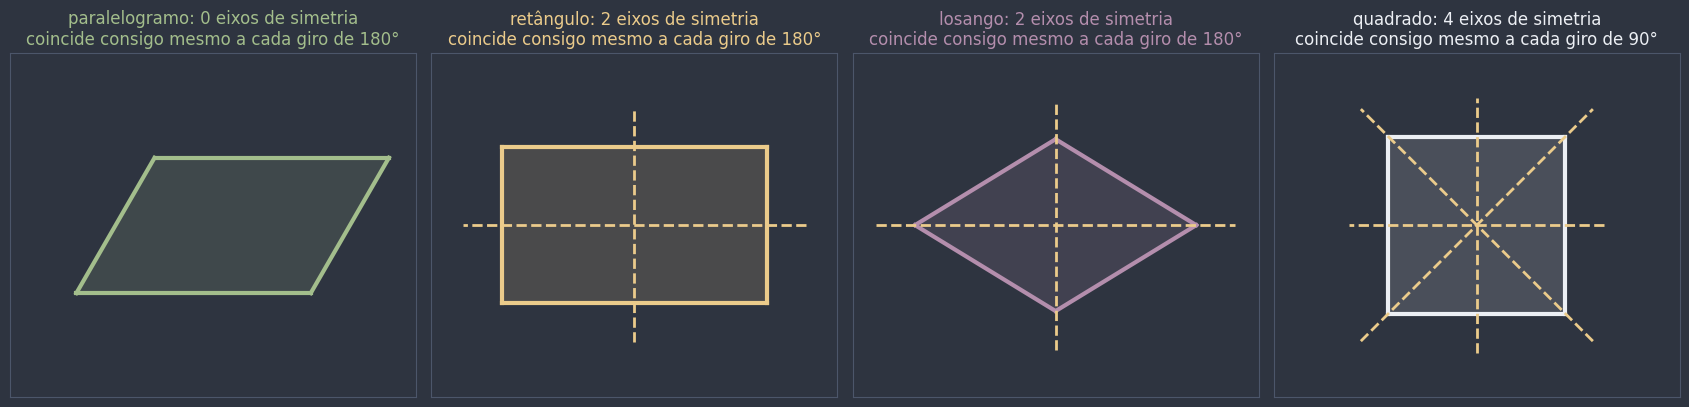

In [22]:
def desenhar_eixo_de_simetria(ax, P, Q, cor: str = COR_AVISO) -> None:
    """Desenha a reta PQ um pouco além dos dois pontos, tracejada: um eixo de simetria."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    ax.plot(*zip(P - 0.5 * u, Q + 0.5 * u), color=cor, lw=2, linestyle="--")


figuras = {
    "paralelogramo": paralelogramo_por_lados(3, 2, 60, origem=(-1.75, -0.87)),
    "retângulo": paralelogramo_por_lados(3.4, 2, 90, origem=(-1.7, -1)),
    "losango": losango_por_diagonais(3.6, 2.2),
    "quadrado": losango_por_diagonais(3.2, 3.2, giro=45),
}
fig, eixos = plt.subplots(1, 4, figsize=(17, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (nome, vertices) in zip(eixos, figuras.items()):
    A, B, C, D = vertices
    preparar_eixo(ax, [(-2.6, -2.2), (2.6, 2.2)], margem=0)
    desenhar_quadrilatero(ax, vertices, cor=CORES_CATEGORIA[nome], largura=3)
    eixos_de_simetria = []
    if nome in ("retângulo", "quadrado"):  # retas pelos pontos médios de lados opostos
        eixos_de_simetria += [(ponto_medio(A, B), ponto_medio(C, D)), (ponto_medio(B, C), ponto_medio(D, A))]
    if nome in ("losango", "quadrado"):  # as diagonais
        eixos_de_simetria += [(A, C), (B, D)]
    for P, Q in eixos_de_simetria:
        desenhar_eixo_de_simetria(ax, P, Q)
    giro = {"paralelogramo": "180°", "retângulo": "180°", "losango": "180°", "quadrado": "90°"}[nome]
    ax.set_title(f"{nome}: {len(eixos_de_simetria)} eixos de simetria\ncoincide consigo mesmo a cada giro de {giro}",
                 color=CORES_CATEGORIA[nome], fontsize=12)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática — computação gráfica e visão computacional:** a tela em que você lê isto é um mosaico de milhões de **quadrados** minúsculos, os pixels, organizados numa grade; uma imagem digital é uma tabela que diz a cor de cada quadradinho. E o caminho inverso também existe: quando o celular "encontra" sozinho uma folha de papel para escanear, um QR Code ou uma placa de carro numa foto, o programa primeiro localiza quatro cantos e depois **testa propriedades**, exatamente como a nossa `classificar_quadrilatero`: os lados opostos são paralelos? Os ângulos são retos (ou quase, por causa da perspectiva)? Classificar formas pelas suas propriedades é uma das ideias básicas da visão computacional.

📖 **Leitura complementar:** [Quadrado](https://pt.wikipedia.org/wiki/Quadrado) e [Quadrilátero](https://pt.wikipedia.org/wiki/Quadril%C3%A1tero) (visão geral da classificação)

**Pergunta de checagem:** todo quadrado é losango? Todo losango é quadrado? Justifique.

**Pergunta de checagem:** as diagonais de um paralelogramo são congruentes **e** perpendiculares. Qual é o nome mais específico desse paralelogramo?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Paralelogramo | quadrilátero com **dois pares** de lados opostos paralelos ($\overline{AB} \parallel \overline{DC}$ e $\overline{AD} \parallel \overline{BC}$); é um trapézio especial |
| Propriedades do paralelogramo | lados opostos ≡; ângulos opostos ≡; ângulos consecutivos suplementares; diagonais se cortam ao meio ($AM = MC$, $BM = MD$) |
| Como se demonstram | uma diagonal + alternos internos + **ALA** ($\triangle ABC \equiv \triangle CDA$); as duas diagonais + ALA ($\triangle ABM \equiv \triangle CDM$) |
| Condições para ser paralelogramo (basta uma) | lados opostos ≡ / ângulos opostos ≡ / diagonais se cortam ao meio / **um** par de lados opostos paralelos **e** ≡ |
| Armadilha | um par ≡ e o **outro** par ∥ não basta: o trapézio isósceles é contraexemplo |
| Com coordenadas | paralelogramo $\iff$ as diagonais têm o mesmo ponto médio $\iff A + C = B + D$ |
| Retângulo | quatro ângulos retos (= paralelogramo com **um** ângulo reto); **diagonais ≡**; recíproca: paralelogramo com diagonais ≡ é retângulo; $M$ equidista dos 4 vértices |
| Losango | quatro lados ≡ (= paralelogramo com dois lados consecutivos ≡); **diagonais ⊥ e bissetrizes**; cada diagonal é a mediatriz da outra |
| Quadrado | retângulo **e** losango: herda tudo; diagonais ≡, ⊥, se cortam ao meio e formam 45° com os lados |
| Hierarquia | quadrilátero $\supset$ trapézio $\supset$ paralelogramo $\supset$ {retângulo, losango} $\supset$ quadrado; as propriedades **descem** |

**A ideia central:** o que **permanece** quando o retângulo tomba (lados opostos paralelos e congruentes, diagonais que se cortam ao meio) é o que define **todo** paralelogramo; o que se **perde** (ângulos retos, diagonais congruentes) era exclusivo do retângulo. Cada caso particular acrescenta propriedades às do nível de cima, e o quadrado, no fundo da hierarquia, tem todas.

## Exercícios

**Básico**
1. Calcular os ângulos de um paralelogramo a partir de um deles, e o outro lado a partir de um lado e do perímetro.
2. Classificar quadriláteros (paralelogramo, retângulo, losango, quadrado, podendo ser mais de um) a partir das medidas dos lados e dos ângulos, e a partir das diagonais.

**Intermediário**

3. Classificar quadriláteros dados por coordenadas olhando **só para as diagonais**, e conferir com a `classificar_quadrilatero` (inclusive um trapézio isósceles e uma pipa, que **não** são paralelogramos).
4. Calcular o lado de um losango a partir das diagonais (com uma prévia do Teorema de Pitágoras).

**Desafio**

5. O teorema de Varignon: ligando os pontos médios dos lados de **qualquer** quadrilátero convexo, sai sempre um paralelogramo.
6. Quando o paralelogramo de Varignon é um retângulo? E um losango?

Gabarito completo com resolução comentada em [`0409b_paralelogramos_e_casos_particulares_gabarito.ipynb`](0409b_paralelogramos_e_casos_particulares_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1:
# (a) Complete a função `angulos_paralelogramo_ex1`, que recebe a medida (em graus) do ângulo Â de
#     um paralelogramo ABCD e devolve a tupla (Â, B̂, Ĉ, D̂) com as medidas dos quatro ângulos.
#     (Lembre: ângulos opostos são congruentes e ângulos consecutivos são suplementares.)
# (b) Complete a função `outro_lado_ex1`, que recebe a medida de um lado de um paralelogramo e o
#     perímetro dele, e devolve a medida do lado consecutivo (o "outro" lado). Se a conta não der
#     um número positivo, não existe paralelogramo com essas medidas: devolva None.
# (c) Um terreno em forma de paralelogramo tem perímetro de 26 m e um dos lados mede 4 m. Quanto
#     mede o outro lado? Guarde em `outro_lado_terreno_ex1`.


def angulos_paralelogramo_ex1(angulo_A: float) -> tuple[float, float, float, float]:
    ...


def outro_lado_ex1(lado: float, perimetro: float) -> float | None:
    ...


outro_lado_terreno_ex1 = ...

print(angulos_paralelogramo_ex1(65))
print(outro_lado_ex1(7, 30), outro_lado_terreno_ex1)

In [ ]:
# Verificação
casos_angulos_ex1 = [(65, (65, 115, 65, 115)), (90, (90, 90, 90, 90)), (120, (120, 60, 120, 60)),
                     (37.5, (37.5, 142.5, 37.5, 142.5))]
for angulo_A, certo in casos_angulos_ex1:
    resposta = angulos_paralelogramo_ex1(angulo_A)
    assert resposta is not None and resposta is not ... and len(resposta) == 4 and all(
        math.isclose(r, c) for r, c in zip(resposta, certo)), (
        f"Tente de novo, revise: com Â = {angulo_A}°, os ângulos (Â, B̂, Ĉ, D̂) são {certo}; opostos iguais e "
        "consecutivos somando 180° (seção 1 - Paralelogramo: definição e propriedades)."
    )
casos_lado_ex1 = [(7, 30, 8), (4, 26, 9), (2.5, 14, 4.5), (5, 20, 5), (10, 20, None), (12, 20, None)]
for lado, perimetro, certo in casos_lado_ex1:
    resposta = outro_lado_ex1(lado, perimetro)
    if certo is None:
        assert resposta is None, (
            f"Tente de novo, revise: com lado {lado} e perímetro {perimetro}, o outro lado daria "
            f"{perimetro / 2 - lado:g}, que não é a medida de um lado: devolva None "
            "(seção 1 - Paralelogramo: definição e propriedades)."
        )
    else:
        assert resposta is not None and resposta is not ... and math.isclose(resposta, certo), (
            f"Tente de novo, revise: o perímetro é 2 × (lado + outro), então o outro lado é {perimetro} / 2 − {lado} "
            f"= {certo} (seção 1 - Paralelogramo: definição e propriedades)."
        )
assert outro_lado_terreno_ex1 is not ... and math.isclose(outro_lado_terreno_ex1, 9), (
    "Tente de novo, revise: os lados opostos são congruentes, então 26 = 2 × (4 + outro) "
    "(seção 1 - Paralelogramo: definição e propriedades)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2:
# (a) Complete a função `classificar_por_medidas_ex2`. Ela recebe a lista dos quatro lados
#     [AB, BC, CD, DA] e a lista dos quatro ângulos [Â, B̂, Ĉ, D̂] de um quadrilátero CONVEXO e devolve
#     o CONJUNTO (set) de categorias a que ele pertence, entre "paralelogramo", "retângulo",
#     "losango" e "quadrado" (pode ser mais de uma, ou nenhuma: set()).
#     Use as regras das seções 2 a 5:
#       - paralelogramo: os lados opostos são congruentes (condição 1 da seção 2);
#       - retângulo: é paralelogramo e os quatro ângulos são retos;
#       - losango: os quatro lados são congruentes;
#       - quadrado: é retângulo e losango.
#     Compare medidas com math.isclose, não com ==.
# (b) Um quadrilátero convexo tem diagonais que se cortam ao meio, são congruentes e são
#     perpendiculares. Qual é o nome mais específico dele? Guarde o texto, em minúsculas, em `nome_ex2`.


def classificar_por_medidas_ex2(lados: list[float], angulos: list[float]) -> set[str]:
    ...


nome_ex2 = ...

print(classificar_por_medidas_ex2([6, 4, 6, 4], [90, 90, 90, 90]))
print(classificar_por_medidas_ex2([5, 5, 5, 5], [60, 120, 60, 120]))
print(nome_ex2)

In [ ]:
# Verificação
casos_ex2 = [
    ([5, 5, 5, 5], [90, 90, 90, 90], {"paralelogramo", "retângulo", "losango", "quadrado"}),
    ([6, 4, 6, 4], [90, 90, 90, 90], {"paralelogramo", "retângulo"}),
    ([5, 5, 5, 5], [60, 120, 60, 120], {"paralelogramo", "losango"}),
    ([6, 4, 6, 4], [70, 110, 70, 110], {"paralelogramo"}),
    ([6, 4, 5, 4], [70, 70, 110, 110], set()),  # trapézio isósceles: um par de lados opostos congruentes só
    ([3, 5, 5, 3], [80, 100, 80, 100], set()),  # pipa
    ([0.1 + 0.2, 0.3, 0.3, 0.3], [90, 90, 90, 90], {"paralelogramo", "retângulo", "losango", "quadrado"}),
]
for lados, angulos, certo in casos_ex2:
    resposta = classificar_por_medidas_ex2(lados, angulos)
    assert resposta is not None and resposta is not ... and set(resposta) == certo, (
        f"Tente de novo, revise: lados {lados} e ângulos {angulos} dão as categorias {certo or 'set()'}, mas a "
        f"função devolveu {resposta!r}; lembre que um quadrado também é retângulo, losango e paralelogramo "
        "(seção 5 - Quadrado e a hierarquia completa)."
    )
assert isinstance(nome_ex2, str) and nome_ex2.strip().lower() == "quadrado", (
    "Tente de novo, revise: diagonais que se cortam ao meio (paralelogramo), congruentes (retângulo) e "
    "perpendiculares (losango) (seção 5 - Quadrado e a hierarquia completa)."
)
print("Certo!")

### Intermediário

Execute a célula abaixo para ver as figuras do Exercício Intermediário 3.

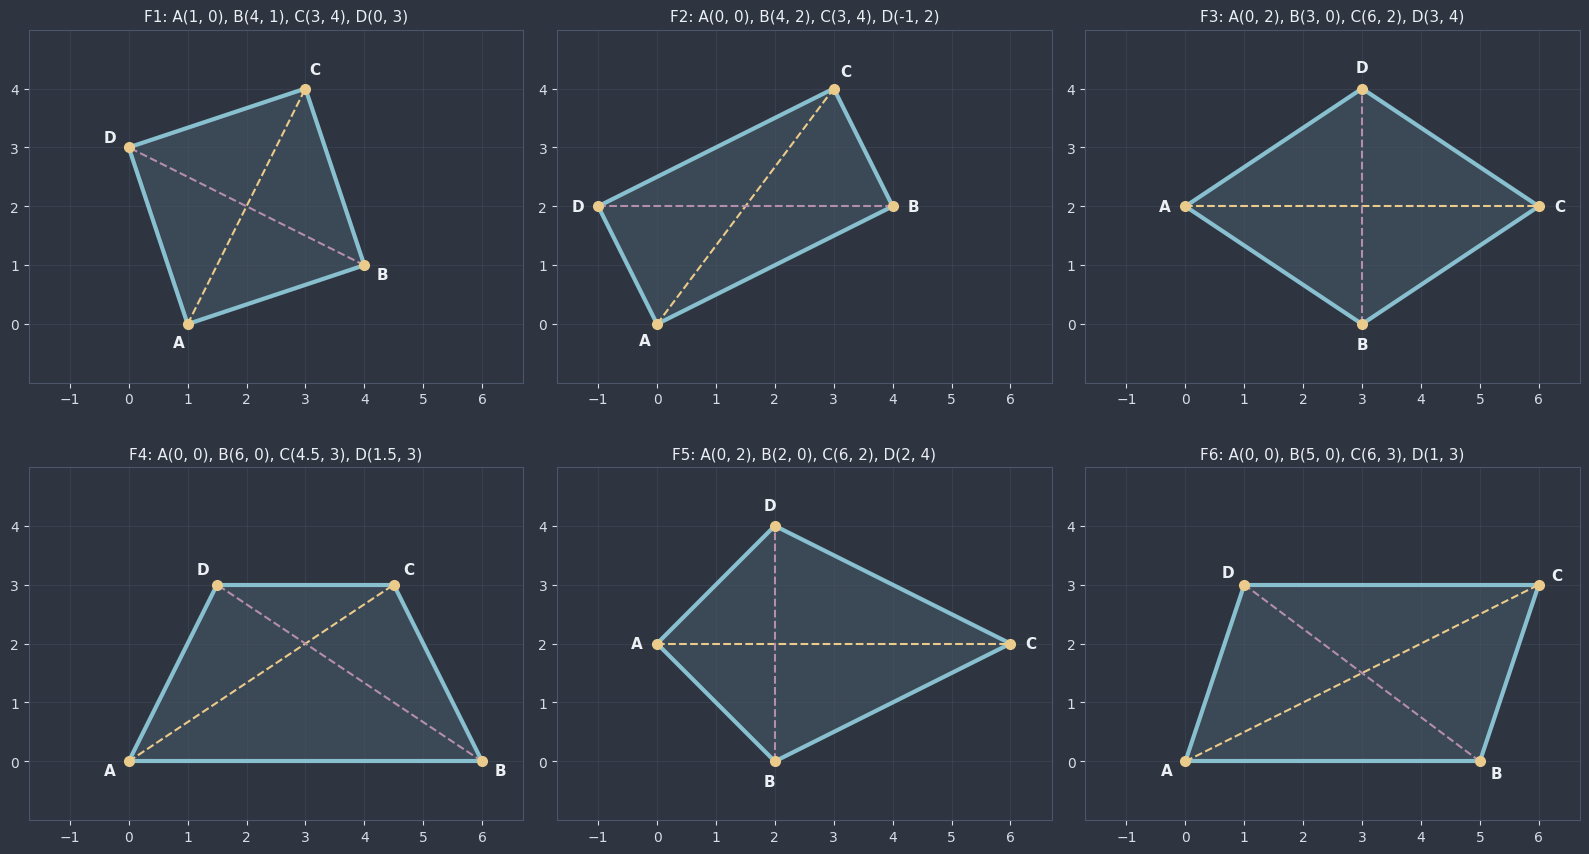

In [23]:
# Figuras do Exercício Intermediário 3 (apenas desenha; não precisa alterar)
FIGURAS_EX3 = {
    "F1": [(1, 0), (4, 1), (3, 4), (0, 3)],
    "F2": [(0, 0), (4, 2), (3, 4), (-1, 2)],
    "F3": [(0, 2), (3, 0), (6, 2), (3, 4)],
    "F4": [(0, 0), (6, 0), (4.5, 3), (1.5, 3)],
    "F5": [(0, 2), (2, 0), (6, 2), (2, 4)],
    "F6": [(0, 0), (5, 0), (6, 3), (1, 3)],
}
FIGURAS_EX3 = {nome: [np.array(v, dtype=float) for v in vertices] for nome, vertices in FIGURAS_EX3.items()}

fig, eixos = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (nome, vertices) in zip(eixos.flat, FIGURAS_EX3.items()):
    preparar_eixo(ax, [(-1.5, -0.8), (6.5, 4.8)], margem=0.2)
    estilizar_eixo(ax)
    ax.set_xticks(range(-1, 7))
    ax.set_yticks(range(0, 5))
    desenhar_quadrilatero(ax, vertices, cor=COR_PONTO, largura=3)
    A, B, C, D = vertices
    ax.plot(*zip(A, C), color=COR_AVISO, lw=1.5, linestyle="--")
    ax.plot(*zip(B, D), color=COR_EXTRA, lw=1.5, linestyle="--")
    rotular_vertices(ax, vertices, distancia=0.35, tamanho=11)
    ax.set_title(f"{nome}: " + ", ".join(f"{letra}({v[0]:g}, {v[1]:g})" for letra, v in zip("ABCD", vertices)),
                 color=NORD_TEXTO, fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Intermediário 3: classificando pelas diagonais.
# (a) Complete a função `analisar_diagonais_ex3`, que recebe os vértices A, B, C, D (np.array) e
#     devolve a tupla (cortam_ao_meio, congruentes, perpendiculares) de valores True/False:
#       - cortam_ao_meio: AC e BD têm o mesmo ponto médio (use ponto_medio e np.allclose);
#       - congruentes: AC e BD têm a mesma medida (math.dist e math.isclose);
#       - perpendiculares: o produto escalar de (C − A) e (D − B) é zero
#         (np.dot e math.isclose(..., 0, abs_tol=1e-9)).
# (b) Complete a função `nome_pelas_diagonais_ex3`, que recebe esses três valores e devolve UM
#     destes textos: "não é paralelogramo", "paralelogramo", "retângulo", "losango" ou "quadrado".
#     (Se as diagonais não se cortam ao meio, não é paralelogramo, não importa o resto.)
# (c) Use as duas funções nas figuras F1 a F6 (dicionário FIGURAS_EX3, da célula acima) e guarde
#     os resultados no dicionário `nomes_ex3`, no formato {"F1": "...", "F2": "...", ...}.
# A verificação vai comparar cada resposta com a função `classificar_quadrilatero` da seção 5.


def analisar_diagonais_ex3(A, B, C, D) -> tuple[bool, bool, bool]:
    ...


def nome_pelas_diagonais_ex3(cortam_ao_meio: bool, congruentes: bool, perpendiculares: bool) -> str:
    ...


nomes_ex3 = ...

print(nomes_ex3)

In [ ]:
# Verificação
def nome_esperado_ex3(vertices) -> str:
    nome = nome_mais_especifico(*vertices)
    return nome if nome in ("paralelogramo", "retângulo", "losango", "quadrado") else "não é paralelogramo"


combinacoes_ex3 = {
    (True, False, False): "paralelogramo", (True, True, False): "retângulo",
    (True, False, True): "losango", (True, True, True): "quadrado",
    (False, False, False): "não é paralelogramo", (False, True, False): "não é paralelogramo",
    (False, False, True): "não é paralelogramo", (False, True, True): "não é paralelogramo",
}
for diagonais, certo in combinacoes_ex3.items():
    assert nome_pelas_diagonais_ex3(*diagonais) == certo, (
        f"Tente de novo, revise: diagonais (cortam ao meio, congruentes, perpendiculares) = {diagonais} "
        f"indicam {certo!r} (seção 2 - Como reconhecer um paralelogramo)."
    )
assert isinstance(nomes_ex3, dict), "Tente de novo, revise: `nomes_ex3` deve ser um dicionário (seção 2 - Como reconhecer um paralelogramo)."
for nome_figura, vertices in FIGURAS_EX3.items():
    certo = nome_esperado_ex3(vertices)
    analise = analisar_diagonais_ex3(*vertices)
    assert analise is not None and analise is not ... and nome_pelas_diagonais_ex3(*analise) == certo, (
        f"Tente de novo, revise: a análise das diagonais de {nome_figura} deveria levar a {certo!r}; confira os "
        "pontos médios, as medidas e o produto escalar (seção 2 - Como reconhecer um paralelogramo)."
    )
    assert nomes_ex3.get(nome_figura) == certo, (
        f"Tente de novo, revise: a figura {nome_figura} é {certo!r} (seção 5 - Quadrado e a hierarquia completa)."
    )
print("Certo!")

In [ ]:
# Exercício Intermediário 4: o lado de um losango a partir das diagonais.
# Um losango tem diagonais de 6 cm e 8 cm. Colocando o centro na origem, com a diagonal de 6 cm na
# horizontal e a de 8 cm na vertical, os vértices são A = (−3, 0), B = (0, −4), C = (3, 0), D = (0, 4).
# (a) As diagonais se cortam ao meio: guarde as semidiagonais (as metades) em `meia_d1_ex4` e
#     `meia_d2_ex4`.
# (b) Use o transferidor digital `medir_angulo` para medir o ângulo AM̂B, com M = (0, 0). Guarde em
#     `angulo_M_ex4`. (Que propriedade do losango esse valor confirma?)
# (c) Meça o lado AB com math.dist e guarde em `lado_ex4`.
# (d) As semidiagonais e o lado formam o triângulo retângulo AMB. Existe uma fórmula famosa que dá
#     o maior lado de um triângulo retângulo a partir dos outros dois: lado = √(meia_d1² + meia_d2²).
#     Calcule com ela (math.sqrt) e guarde em `lado_formula_ex4`. Ela confere com o item (c)?
# (e) Calcule o perímetro do losango e guarde em `perimetro_ex4`.
A_ex4, B_ex4, C_ex4, D_ex4 = (np.array(p, dtype=float) for p in [(-3, 0), (0, -4), (3, 0), (0, 4)])
M_ex4 = np.array([0.0, 0.0])

meia_d1_ex4 = ...
meia_d2_ex4 = ...
angulo_M_ex4 = ...
lado_ex4 = ...
lado_formula_ex4 = ...
perimetro_ex4 = ...

print(meia_d1_ex4, meia_d2_ex4, angulo_M_ex4)
print(lado_ex4, lado_formula_ex4, perimetro_ex4)

In [ ]:
# Verificação
assert meia_d1_ex4 is not ... and meia_d2_ex4 is not ... and sorted([meia_d1_ex4, meia_d2_ex4]) == [3, 4], (
    "Tente de novo, revise: as diagonais se cortam ao meio, então as metades são 6/2 e 8/2 "
    "(seção 1 - Paralelogramo: definição e propriedades)."
)
assert angulo_M_ex4 is not ... and math.isclose(angulo_M_ex4, 90), (
    "Tente de novo, revise: angulo_M = medir_angulo(M_ex4, A_ex4, B_ex4); as diagonais do losango são "
    "perpendiculares (seção 4 - Losango)."
)
assert lado_ex4 is not ... and math.isclose(lado_ex4, 5), (
    "Tente de novo, revise: lado = math.dist(A_ex4, B_ex4) (seção 4 - Losango)."
)
assert lado_formula_ex4 is not ... and math.isclose(lado_formula_ex4, 5), (
    "Tente de novo, revise: math.sqrt(meia_d1_ex4 ** 2 + meia_d2_ex4 ** 2) (seção 4 - Losango)."
)
assert perimetro_ex4 is not ... and math.isclose(perimetro_ex4, 20), (
    "Tente de novo, revise: os quatro lados do losango são congruentes, então o perímetro é 4 × lado "
    "(seção 4 - Losango)."
)
print("Certo!")

📎 **Conexão:** a fórmula do item (d) do Exercício 4 é o **Teorema de Pitágoras**: num triângulo retângulo, o quadrado da hipotenusa é a soma dos quadrados dos catetos. Aqui ela foi só usada (e conferida com `math.dist`); a demonstração e as aplicações vêm em 📌 Triângulos Retângulos.

### Desafio

Execute a célula abaixo para ver a figura do Exercício Desafio 5.

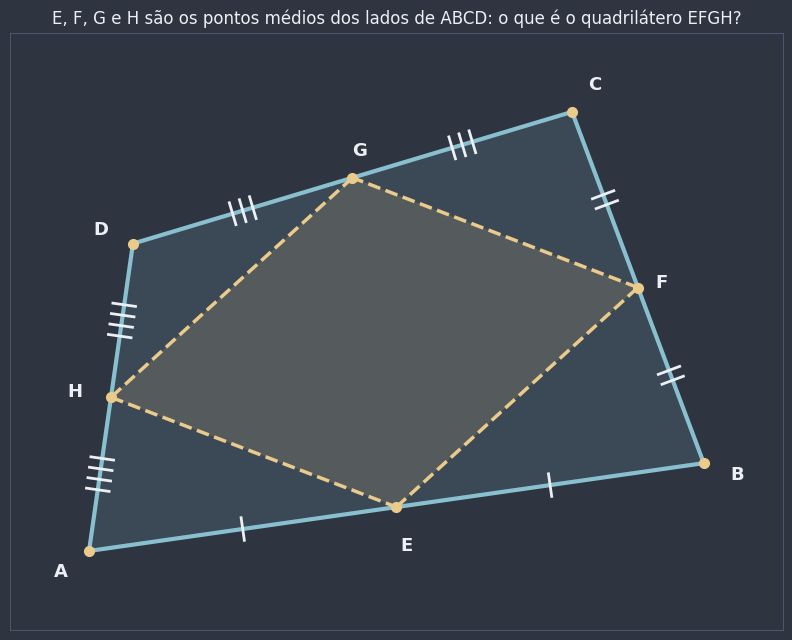

In [24]:
# Figura do Exercício Desafio 5 (apenas desenha; não precisa alterar)
quadrilatero_5 = [np.array(v, dtype=float) for v in [(0, 0), (7, 1), (5.5, 5), (0.5, 3.5)]]
A5, B5, C5, D5 = quadrilatero_5
E5, F5, G5, H5 = ponto_medio(A5, B5), ponto_medio(B5, C5), ponto_medio(C5, D5), ponto_medio(D5, A5)
fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, quadrilatero_5, margem=0.9)
desenhar_quadrilatero(ax, quadrilatero_5, cor=COR_PONTO, largura=3)
ax.add_patch(Polygon([E5, F5, G5, H5], closed=True, facecolor=COR_AVISO, alpha=0.15, edgecolor="none"))
for P, Q in ((E5, F5), (F5, G5), (G5, H5), (H5, E5)):
    ax.plot(*zip(P, Q), color=COR_AVISO, lw=2.5, linestyle="--")
for P, Q, M_lado, tracos in ((A5, B5, E5, 1), (B5, C5, F5, 2), (C5, D5, G5, 3), (D5, A5, H5, 4)):
    marcar_congruentes(ax, P, M_lado, tracos, tamanho=0.13)
    marcar_congruentes(ax, M_lado, Q, tracos, tamanho=0.13)
rotular_vertices(ax, quadrilatero_5, distancia=0.4)
for P, nome, deslocamento in ((E5, "E", (0.05, -0.5)), (F5, "F", (0.2, 0.0)), (G5, "G", (0.0, 0.25)),
                              (H5, "H", (-0.5, 0.0))):
    desenhar_ponto(ax, P, nome, cor=COR_AVISO, deslocamento=deslocamento)
ax.set_title("E, F, G e H são os pontos médios dos lados de ABCD: o que é o quadrilátero EFGH?",
             color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Desafio 5: o teorema de Varignon.
# (a) Complete a função `pontos_medios_ex5`, que recebe os vértices A, B, C, D (np.array) e devolve
#     a lista [E, F, G, H] dos pontos médios de AB, BC, CD e DA, nessa ordem.
# (b) Para o quadrilátero da figura (A5, B5, C5, D5), calcule E, F, G, H e verifique a condição 3
#     da seção 2 no quadrilátero EFGH: as diagonais EG e FH têm o mesmo ponto médio? Guarde
#     True ou False em `mesmo_meio_ex5`.
# (c) Ainda na figura: o lado EF é paralelo à diagonal AC de ABCD? Guarde em `EF_paralelo_AC_ex5`
#     (use sao_paralelos). E quanto vale a razão EF / AC? Guarde em `razao_EF_AC_ex5`.
#     (Pense na base média de um triângulo, de 0408a: qual triângulo tem E e F como pontos médios?)
# (d) Um exemplo só não prova nada. Com o gerador abaixo, sorteie quadriláteros (cada vértice com
#     coordenadas entre −10 e 10: gerador_ex5.uniform(-10, 10, (4, 2))), descarte os que não forem
#     convexos (tipo_de_quadrilatero(...) != "convexo") até juntar 1000 convexos, e guarde em
#     `todos_paralelogramos_ex5` True se, em TODOS eles, o EFGH tiver diagonais com o mesmo ponto médio.
gerador_ex5 = np.random.default_rng(5)


def pontos_medios_ex5(A, B, C, D) -> list[np.ndarray]:
    ...


mesmo_meio_ex5 = ...
EF_paralelo_AC_ex5 = ...
razao_EF_AC_ex5 = ...
todos_paralelogramos_ex5 = ...

print(pontos_medios_ex5(A5, B5, C5, D5))
print(mesmo_meio_ex5, EF_paralelo_AC_ex5, razao_EF_AC_ex5, todos_paralelogramos_ex5)

In [ ]:
# Verificação
pontos_ex5 = pontos_medios_ex5(A5, B5, C5, D5)
assert pontos_ex5 is not None and pontos_ex5 is not ... and len(pontos_ex5) == 4 and all(
    np.allclose(p, c) for p, c in zip(pontos_ex5, [E5, F5, G5, H5])), (
    "Tente de novo, revise: E = ponto_medio(A, B), F = ponto_medio(B, C), G = ponto_medio(C, D), "
    "H = ponto_medio(D, A), nessa ordem (seção 2 - Como reconhecer um paralelogramo)."
)
assert mesmo_meio_ex5 is True or mesmo_meio_ex5 is np.True_, (
    "Tente de novo, revise: compare ponto_medio(E, G) com ponto_medio(F, H) usando np.allclose "
    "(seção 2 - Como reconhecer um paralelogramo)."
)
assert EF_paralelo_AC_ex5 is True or EF_paralelo_AC_ex5 is np.True_, (
    "Tente de novo, revise: EF é a base média do triângulo ABC, paralela a AC (seção 2 - Como reconhecer um paralelogramo)."
)
assert razao_EF_AC_ex5 is not ... and math.isclose(razao_EF_AC_ex5, 0.5), (
    "Tente de novo, revise: razao = math.dist(E, F) / math.dist(A5, C5); a base média mede metade do lado "
    "(seção 2 - Como reconhecer um paralelogramo)."
)
assert todos_paralelogramos_ex5 is True or todos_paralelogramos_ex5 is np.True_, (
    "Tente de novo, revise: em todo quadrilátero, EFGH é paralelogramo; confira o laço, o descarte dos não "
    "convexos e a comparação com np.allclose (seção 2 - Como reconhecer um paralelogramo)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: quando o paralelogramo de Varignon é especial?
# O dicionário abaixo tem quatro quadriláteros convexos.
# (a) Para cada um, calcule o quadrilátero dos pontos médios (use `pontos_medios_ex5`, do desafio
#     anterior) e o nome mais específico dele (use `nome_mais_especifico`, da seção 5). Guarde em
#     `nomes_varignon_ex6`, no formato {"pipa": "...", ...}.
# (b) Para cada quadrilátero ORIGINAL, verifique se as diagonais AC e BD são congruentes e se são
#     perpendiculares. Guarde em `diagonais_ex6`, no formato {"pipa": (congruentes, perpendiculares), ...}.
# (c) Compare (a) com (b) e complete as conclusões, escolhendo entre os textos
#     "diagonais congruentes" e "diagonais perpendiculares":
#       - o paralelogramo de Varignon é um retângulo quando o quadrilátero original tem ...
#         -> guarde em `condicao_retangulo_ex6`
#       - o paralelogramo de Varignon é um losango quando o quadrilátero original tem ...
#         -> guarde em `condicao_losango_ex6`
QUADRILATEROS_EX6 = {
    "pipa": [(0, 2), (2, 0), (6, 2), (2, 4)],
    "trapézio isósceles": [(0, 0), (6, 0), (4.5, 3), (1.5, 3)],
    "diagonais ≡ e ⊥": [(0, 2), (2, -1), (6, 2), (2, 5)],
    "qualquer": [(0, 0), (5, 1), (4, 4), (1, 3)],
}
QUADRILATEROS_EX6 = {nome: [np.array(v, dtype=float) for v in vertices] for nome, vertices in QUADRILATEROS_EX6.items()}

nomes_varignon_ex6 = ...
diagonais_ex6 = ...
condicao_retangulo_ex6 = ...
condicao_losango_ex6 = ...

print(nomes_varignon_ex6)
print(diagonais_ex6)
print(condicao_retangulo_ex6, "|", condicao_losango_ex6)

In [ ]:
# Verificação
certos_ex6 = {"pipa": "retângulo", "trapézio isósceles": "losango", "diagonais ≡ e ⊥": "quadrado",
              "qualquer": "paralelogramo"}
diagonais_certas_ex6 = {"pipa": (False, True), "trapézio isósceles": (True, False), "diagonais ≡ e ⊥": (True, True),
                        "qualquer": (False, False)}
assert isinstance(nomes_varignon_ex6, dict) and isinstance(diagonais_ex6, dict), (
    "Tente de novo, revise: `nomes_varignon_ex6` e `diagonais_ex6` devem ser dicionários "
    "(seção 5 - Quadrado e a hierarquia completa)."
)
for nome, certo in certos_ex6.items():
    assert nomes_varignon_ex6.get(nome) == certo, (
        f"Tente de novo, revise: o quadrilátero dos pontos médios de {nome!r} é um {certo}; use "
        "nome_mais_especifico(*pontos_medios_ex5(*vertices)) (seção 5 - Quadrado e a hierarquia completa)."
    )
    resposta = diagonais_ex6.get(nome)
    assert resposta is not None and tuple(bool(x) for x in resposta) == diagonais_certas_ex6[nome], (
        f"Tente de novo, revise: para {nome!r}, (congruentes, perpendiculares) = {diagonais_certas_ex6[nome]}; "
        "compare math.dist(A, C) com math.dist(B, D) e calcule o produto escalar (seção 4 - Losango)."
    )
assert condicao_retangulo_ex6 == "diagonais perpendiculares", (
    "Tente de novo, revise: compare as figuras cujo Varignon é retângulo (pipa e 'diagonais ≡ e ⊥'): o que as "
    "diagonais delas têm em comum? (seção 3 - Retângulo)."
)
assert condicao_losango_ex6 == "diagonais congruentes", (
    "Tente de novo, revise: compare as figuras cujo Varignon é losango (trapézio isósceles e 'diagonais ≡ e ⊥') "
    "(seção 4 - Losango)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (ponto médio, usado na condição das diagonais e no teorema de Varignon)
- [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb) (casos ALA, LAL e LLL em todas as demonstrações; a propriedade do isósceles por trás das diagonais do losango; o Desafio 5, que este notebook completa)
- [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (alternos internos e colaterais internos entre paralelas, e as recíprocas que viram testes de paralelismo)
- [`0407a_perpendicularidade.ipynb`](0407a_perpendicularidade.ipynb) (ângulo reto e mediatriz: cada diagonal do losango é a mediatriz da outra)
- [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) (definição de quadrilátero, soma 360°, o mapa dos notáveis na convenção inclusiva e a base média do triângulo)

**Isso será usado em:**
- [`0410a_pontos_notaveis_do_triangulo.ipynb`](0410a_pontos_notaveis_do_triangulo.ipynb) (mediana, altura e bissetriz no triângulo isósceles, e as ideias de mediatriz que apareceram nas diagonais do losango)
- 📌 Polígonos (os quadriláteros como o caso $n = 4$ dos polígonos, e o quadrado como o primeiro polígono regular com mais de três lados)
- 📌 Circunferência e Círculo (o retângulo inscrito numa circunferência de centro $M$; quadriláteros inscritíveis e circunscritíveis)
- 📌 Triângulos Retângulos (o Teorema de Pitágoras, usado aqui só de forma antecipada no lado do losango)
- 📌 Equivalência Plana (transformar um paralelogramo num retângulo de mesma área, cortando e colando um triângulo)
- 📌 Áreas de Superfícies Planas (áreas do paralelogramo, do retângulo, do losango a partir das diagonais e do quadrado)
- 📌 Geometria Analítica (a condição "as diagonais têm o mesmo ponto médio", em coordenadas, para reconhecer paralelogramos e achar o quarto vértice)